# 1. Pipeline de inferencia Progressive U-Net + postprocesamiento geométrico + MLflow/Databricks

El objetivo de este notebook es:

1. Recuperar el mejor checkpoint de Progressive U-Net desde Databricks MLflow artifacts.
2. Ejecutar inferencia binaria: vértebra vs fondo.
3. Aplicar postprocesamiento geométrico:
   - componentes conectados,
   - filtrado por área,
   - rectángulos rotados,
   - estimación de Cobb angle,
   - clasificación de severidad.
4. Guardar visualizaciones como artifacts en MLflow/Databricks.
5. Adicionalmente registrar una versión `pyfunc` del pipeline completo: modelo + postprocesamiento.

> Importante: este notebook asume el experimento Experimento B ya existe en databricks y los fold de los checkpoints `best_model_fold_X.pth` y el summary `experiment_b_summary.csv` existen.


## 1. Imports y configuración general

In [1]:
!pip install -q mlflow databricks-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.5/891.5 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import json
import glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pyfunc
from mlflow.tracking import MlflowClient
from sklearn.model_selection import GroupKFold

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
import os

print(os.listdir("/content/drive") if os.path.exists("/content/drive") else "No existe /content/drive")

['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']


In [5]:
# ============================================================
# CONFIGURACIÓN - AJUSTAR SEGÚN TU ENTORNO
# ============================================================

# MLflow / Databricks
MLFLOW_TRACKING_URI = "databricks"
MLFLOW_EXPERIMENT_NAME = "/Users/sl.lancheros20@uniandes.edu.co/spine_segmentation_progressive_unet"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Rutas del proyecto
BASE_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"
OUTPUT_ROOT = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/progressive_geom/mlflow_outputs"
MODEL_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, "progressive_unet_binary_pipeline")

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Config del Experimento B
EXPERIMENT_B_CONFIG = {
    "run_name": "exp_b_progressive_unet_binary_paper_like",
    "img_size": (1024, 512),  # width, height para cv2.resize
    "batch_size": 1,
    "n_splits": 4,
    "in_channels": 1,
    "out_channels": 1,
    "base_channels": 32,
    "dropout": 0.25,
    "threshold": 0.5,
    "min_area": 100,
    "min_gap": 2,
    "model_type": "ProgressiveUNetBinaryPaperLike",
    "task": "binary_vertebra_segmentation_with_cobb_postprocessing",
}

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Output dir:", MODEL_OUTPUT_DIR)


MLflow tracking URI: databricks
Output dir: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/progressive_geom/mlflow_outputs/progressive_unet_binary_pipeline


## 2. Cargar `df_input`



- `image_path`
- `mask_path`
- `patient_id`




In [6]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os
import pandas as pd

PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"
DF_INPUT_PATH = os.path.join(PATH, "indice_dataset.csv")

print("PATH:", PATH)
print("Existe PATH?", os.path.exists(PATH))
print("DF_INPUT_PATH:", DF_INPUT_PATH)
print("Existe DF_INPUT_PATH?", os.path.exists(DF_INPUT_PATH))

if os.path.exists(DF_INPUT_PATH):
    df_input = pd.read_csv(DF_INPUT_PATH)
    print("df_input cargado:", DF_INPUT_PATH)
else:
    print("No se encontró DF_INPUT_PATH.")
    print("Archivos en PATH:")
    if os.path.exists(PATH):
        print(os.listdir(PATH))
    df_input = pd.DataFrame(columns=["image_path", "mask_path", "patient_id"])

display(df_input.head())
print("Shape:", df_input.shape)

Mounted at /content/drive
PATH: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes
Existe PATH? True
DF_INPUT_PATH: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/indice_dataset.csv
Existe DF_INPUT_PATH? True
df_input cargado: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/indice_dataset.csv


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN


Shape: (250, 9)


## 3. Modelo Progressive U-Net binario tipo paper

In [7]:
class PaperConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.25):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class ProgressiveUNetBinaryPaperLike(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=32,
        dropout=0.25,
    ):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8
        c5 = base_channels * 16

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = PaperConvBlock(in_channels, c1, dropout=dropout)
        self.enc2 = PaperConvBlock(c1, c2, dropout=dropout)
        self.enc3 = PaperConvBlock(c2, c3, dropout=dropout)
        self.enc4 = PaperConvBlock(c3, c4, dropout=dropout)

        self.bottleneck = PaperConvBlock(c4, c5, dropout=dropout)

        self.up4 = nn.ConvTranspose2d(c5, c4, kernel_size=2, stride=2)
        self.dec4 = PaperConvBlock(c4 + c4, c4, dropout=dropout)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = PaperConvBlock(c3 + c3, c3, dropout=dropout)

        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = PaperConvBlock(c2 + c2, c2, dropout=dropout)

        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = PaperConvBlock(c1 + c1, c1, dropout=dropout)

        self.side4 = nn.Conv2d(c4, out_channels, kernel_size=1)
        self.side3 = nn.Conv2d(c3, out_channels, kernel_size=1)
        self.side2 = nn.Conv2d(c2, out_channels, kernel_size=1)

        self.final_conv = nn.Conv2d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        side4 = self.side4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        side4_up = F.interpolate(side4, size=d3.shape[-2:], mode="bilinear", align_corners=False)
        side3 = self.side3(d3) + side4_up

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        side3_up = F.interpolate(side3, size=d2.shape[-2:], mode="bilinear", align_corners=False)
        side2 = self.side2(d2) + side3_up

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        side2_up = F.interpolate(side2, size=d1.shape[-2:], mode="bilinear", align_corners=False)
        logits = self.final_conv(d1) + side2_up

        if logits.shape[-2:] != input_size:
            logits = F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)

        return logits


## 4. Dataset binario para inferencia y validación

Convierte cualquier máscara multiclase `> 0` a foreground vertebral.


In [8]:
df_input.columns

Index(['grupo', 'imagen', 'id_paciente', 'ruta_radiografia',
       'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png',
       'ruta_mascara_multiclase_grises_jpg',
       'ruta_mascara_multiclase_color_jpg', 'metricas_json'],
      dtype='object')

In [9]:
class BinarySpineSegmentationDataset(Dataset):
    def __init__(
        self,
        dataframe,
        base_dir,
        img_size=(1024, 512),
        image_col="ruta_radiografia",
        mask_col="ruta_mascara_binaria",
    ):
        self.df = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.img_size = img_size
        self.image_col = image_col
        self.mask_col = mask_col

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, path_value):
        path_value = str(path_value)

        if os.path.isabs(path_value):
            return path_value

        return os.path.join(self.base_dir, path_value)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self._resolve_path(row[self.image_col])
        mask_path = self._resolve_path(row[self.mask_col])

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"No se pudo cargar la imagen: {image_path}")

        image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)

        sample = {
            "image": torch.tensor(image, dtype=torch.float32),
            "image_path": image_path,
        }

        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

            if mask is None:
                raise ValueError(f"No se pudo cargar la máscara: {mask_path}")

            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

            if mask.ndim == 3:
                mask = mask[:, :, 0]

            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=0)

            sample["mask"] = torch.tensor(mask, dtype=torch.float32)
            sample["mask_path"] = mask_path

        return sample


## 5. Postprocesamiento geométrico

Este bloque toma una máscara binaria predicha y estima componentes vertebrales, Cobb angle y severidad.


In [10]:
def extract_vertebra_components(binary_mask, min_area=100):
    mask_uint8 = (binary_mask > 0).astype(np.uint8)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask_uint8,
        connectivity=8,
    )

    components = []

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area < min_area:
            continue

        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]
        cx, cy = centroids[label_id]

        component_mask = (labels == label_id).astype(np.uint8)

        components.append({
            "label_id": int(label_id),
            "area": int(area),
            "bbox": (int(x), int(y), int(w), int(h)),
            "centroid": (float(cx), float(cy)),
            "mask": component_mask,
        })

    return components


def order_components_top_to_bottom(components):
    return sorted(components, key=lambda c: c["centroid"][1])


def add_rotated_rect_info(components):
    enriched = []

    for comp in components:
        mask = comp["mask"]

        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )

        if len(contours) == 0:
            continue

        contour = max(contours, key=cv2.contourArea)

        if cv2.contourArea(contour) <= 0:
            continue

        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect)
        box = np.int32(box)

        comp = comp.copy()
        comp["contour"] = contour
        comp["rotated_rect"] = rect
        comp["box_points"] = box

        enriched.append(comp)

    return enriched


def get_top_bottom_edges_from_box(box_points):
    pts = np.array(box_points, dtype=np.float32)

    pts_sorted_y = pts[np.argsort(pts[:, 1])]

    top_two = pts_sorted_y[:2]
    bottom_two = pts_sorted_y[2:]

    top_two = top_two[np.argsort(top_two[:, 0])]
    bottom_two = bottom_two[np.argsort(bottom_two[:, 0])]

    top_edge = (top_two[0], top_two[1])
    bottom_edge = (bottom_two[0], bottom_two[1])

    return top_edge, bottom_edge


def slope_from_edge(edge, eps=1e-6):
    p1, p2 = edge

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    if abs(dx) < eps:
        return np.inf

    return dy / dx


def cobb_angle_from_slopes(m_upper, m_lower):
    if np.isinf(m_upper) and np.isinf(m_lower):
        return 0.0

    angle_upper = np.pi / 2 if np.isinf(m_upper) else np.arctan(m_upper)
    angle_lower = np.pi / 2 if np.isinf(m_lower) else np.arctan(m_lower)

    theta = abs(angle_upper - angle_lower)
    theta_deg = np.degrees(theta)

    if theta_deg > 90:
        theta_deg = 180 - theta_deg

    return float(theta_deg)


def classify_scoliosis_severity(cobb_angle):
    if cobb_angle < 10:
        return "normal"
    elif cobb_angle < 25:
        return "mild"
    elif cobb_angle < 45:
        return "moderate"
    else:
        return "severe"


def estimate_cobb_angle_from_components(components, min_gap=2):
    components = order_components_top_to_bottom(components)
    components = add_rotated_rect_info(components)

    vertebrae = []

    for idx, comp in enumerate(components):
        box = comp["box_points"]

        top_edge, bottom_edge = get_top_bottom_edges_from_box(box)

        top_slope = slope_from_edge(top_edge)
        bottom_slope = slope_from_edge(bottom_edge)

        vertebrae.append({
            "index": idx,
            "component": comp,
            "top_edge": top_edge,
            "bottom_edge": bottom_edge,
            "top_slope": top_slope,
            "bottom_slope": bottom_slope,
            "centroid": comp["centroid"],
            "box_points": box,
        })

    best = None

    for i in range(len(vertebrae)):
        for j in range(i + min_gap, len(vertebrae)):
            upper = vertebrae[i]
            lower = vertebrae[j]

            angle = cobb_angle_from_slopes(
                upper["top_slope"],
                lower["bottom_slope"],
            )

            if best is None or angle > best["cobb_angle"]:
                best = {
                    "upper_index": i,
                    "lower_index": j,
                    "upper": upper,
                    "lower": lower,
                    "cobb_angle": angle,
                }

    return best, vertebrae


def postprocess_binary_spine_mask(
    binary_mask,
    min_area=100,
    min_gap=2,
):
    components = extract_vertebra_components(
        binary_mask=binary_mask,
        min_area=min_area,
    )

    components = order_components_top_to_bottom(components)

    result, vertebrae = estimate_cobb_angle_from_components(
        components,
        min_gap=min_gap,
    )

    if result is None:
        return {
            "success": False,
            "num_components": len(components),
            "cobb_angle": np.nan,
            "severity": None,
            "is_scoliotic": None,
            "vertebrae": vertebrae,
            "result": None,
        }

    cobb_angle = result["cobb_angle"]
    severity = classify_scoliosis_severity(cobb_angle)

    return {
        "success": True,
        "num_components": len(components),
        "cobb_angle": cobb_angle,
        "severity": severity,
        "is_scoliotic": cobb_angle >= 10,
        "vertebrae": vertebrae,
        "result": result,
    }


## 6. Recuperar el mejor modelo desde Databricks artifacts

Esta sección busca el run con mejor `cv_mean_val_dice`, descarga el `experiment_b_summary.csv`, selecciona el mejor fold y descarga su checkpoint.


In [11]:
import os
from google.colab import userdata

os.environ["DATABRICKS_HOST"] = userdata.get("DBRICKS_HOST")
os.environ["DATABRICKS_TOKEN"] = userdata.get("DBRICKS_TOKEN")

In [12]:
client = MlflowClient()

experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)

if experiment is None:
    raise ValueError(f"No existe el experimento en MLflow: {MLFLOW_EXPERIMENT_NAME}")

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.cv_mean_val_dice DESC"],
    max_results=20,
)

cols_to_show = [
    "run_id",
    "tags.mlflow.runName",
    "metrics.cv_mean_val_dice",
    "metrics.cv_mean_val_iou",
    "metrics.cv_mean_val_f1",
]

existing_cols = [c for c in cols_to_show if c in runs_df.columns]
display(runs_df[existing_cols].head(20))


,run_id,tags.mlflow.runName,metrics.cv_mean_val_dice,metrics.cv_mean_val_iou,metrics.cv_mean_val_f1
0,086ba35fc5f147798715afc67fb69473,exp_b_progressive_unet_binary_paper_like,0.825003,0.707722,0.825003
1,e3df9ae204234af0891806c9a208efe8,progressive_unet_bs4_lr1e4_wd1e4,0.284026,0.208541,NaN
2,3d3fbe41f3e24b7b9175f95b4249f9db,progressive_unet_bs4_lr1e4_wd1e4,0.280812,0.205358,NaN
3,dfec171782a6464daab540bf896f0178,progressive_unet_bs4_lr1e4_wd1e4,0.220371,0.161131,NaN
4,964846ca067a4370bb427aae9ab8c9e3,progressive_unet_bs4_lr1e4_wd1e4,0.211672,0.156696,NaN
5,ce49860a7eac49ad9b6491072f1e5695,exp_b_progressive_unet_binary_paper_like_pyfun...,NaN,NaN,NaN
6,fbeaddd752534b829019cc8310cf32eb,exp_b_progressive_unet_binary_paper_like_infer...,NaN,NaN,NaN
7,334a1ee3dd8b461da6256d9779a16b22,exp_b_progressive_unet_binary_paper_like_pyfun...,NaN,NaN,NaN
8,1c1caca30c8a465bb1636b6c8d7753e2,exp_b_progressive_unet_binary_paper_like_infer...,NaN,NaN,NaN
9,67fca6c3f56347cd8267a5f333d77a14,exp_b_progressive_unet_binary_paper_like_pyfun...,NaN,NaN,NaN


In [13]:
# Seleccionar el RUN_ID.
# Por defecto usa el primero de la tabla anterior.
#RUN_ID = runs_df.iloc[0]["run_id"]
RUN_ID ="086ba35fc5f147798715afc67fb69473"

print("RUN_ID seleccionado:", RUN_ID)

DOWNLOAD_DIR = os.path.join(MODEL_OUTPUT_DIR, "downloaded_databricks_artifacts")
os.makedirs(DOWNLOAD_DIR, exist_ok=True)


def list_artifacts_recursive(client, run_id, path=""):
    items = client.list_artifacts(run_id, path)
    all_items = []

    for item in items:
        all_items.append(item.path)
        if item.is_dir:
            all_items.extend(list_artifacts_recursive(client, run_id, item.path))

    return all_items


artifact_paths = list_artifacts_recursive(client, RUN_ID)

print("Artifacts encontrados:")
for p in artifact_paths:
    print(" -", p)


RUN_ID seleccionado: 086ba35fc5f147798715afc67fb69473
Artifacts encontrados:
 - config
 - config/experiment_b_config.json
 - fold_1
 - fold_1/checkpoints
 - fold_1/checkpoints/best_model_fold_1.pth
 - fold_1/history
 - fold_1/history/history_fold_1.csv
 - fold_2
 - fold_2/checkpoints
 - fold_2/checkpoints/best_model_fold_2.pth
 - fold_2/history
 - fold_2/history/history_fold_2.csv
 - fold_3
 - fold_3/checkpoints
 - fold_3/checkpoints/best_model_fold_3.pth
 - fold_3/history
 - fold_3/history/history_fold_3.csv
 - fold_4
 - fold_4/checkpoints
 - fold_4/checkpoints/best_model_fold_4.pth
 - fold_4/history
 - fold_4/history/history_fold_4.csv
 - results
 - results/experiment_b_all_histories.csv
 - results/experiment_b_summary.csv


In [14]:
# Ajustar la ruta al summary
SUMMARY_ARTIFACT_PATH = "results/experiment_b_summary.csv"

local_summary_path = client.download_artifacts(
    run_id=RUN_ID,
    path=SUMMARY_ARTIFACT_PATH,
    dst_path=DOWNLOAD_DIR,
)

summary_df_b_dbx = pd.read_csv(local_summary_path)
display(summary_df_b_dbx)

best_row = summary_df_b_dbx.loc[summary_df_b_dbx["val_dice"].idxmax()]
best_fold = int(best_row["fold"])

print("Best fold:", best_fold)
print("Best val Dice:", float(best_row["val_dice"]))

CHECKPOINT_ARTIFACT_PATH = f"fold_{best_fold}/checkpoints/best_model_fold_{best_fold}.pth"

local_checkpoint_path = client.download_artifacts(
    run_id=RUN_ID,
    path=CHECKPOINT_ARTIFACT_PATH,
    dst_path=DOWNLOAD_DIR,
)

print("Checkpoint descargado:", local_checkpoint_path)


,experiment,fold,epoch,train_loss,train_dice,train_iou,train_f1,train_precision,train_recall,train_acc,...,val_f1,val_precision,val_recall,val_acc,lr,best_model_path,best_epoch,run_name,model_type,task
0,B,1,59,0.137615,0.850350,0.741410,0.850350,0.807180,0.903100,0.964048,...,0.823220,0.792693,0.864635,0.955622,0.0001,/content/mlflow_outputs/progressive_unet/exp_b...,59,exp_b_progressive_unet_binary_paper_like,ProgressiveUNetBinaryPaperLike,binary_vertebra_segmentation
1,B,2,59,0.140437,0.847431,0.737690,0.847431,0.810066,0.893460,0.962632,...,0.833918,0.790519,0.889768,0.961647,0.0001,/content/mlflow_outputs/progressive_unet/exp_b...,59,exp_b_progressive_unet_binary_paper_like,ProgressiveUNetBinaryPaperLike,binary_vertebra_segmentation
2,B,3,54,0.141530,0.846356,0.736186,0.846356,0.806051,0.896583,0.962815,...,0.821619,0.784135,0.869539,0.957729,0.0001,/content/mlflow_outputs/progressive_unet/exp_b...,54,exp_b_progressive_unet_binary_paper_like,ProgressiveUNetBinaryPaperLike,binary_vertebra_segmentation
3,B,4,60,0.141498,0.846499,0.736116,0.846499,0.806100,0.895784,0.962780,...,0.821256,0.781869,0.874234,0.957271,0.0001,/content/mlflow_outputs/progressive_unet/exp_b...,60,exp_b_progressive_unet_binary_paper_like,ProgressiveUNetBinaryPaperLike,binary_vertebra_segmentation


Best fold: 2
Best val Dice: 0.8339182718154279


Checkpoint descargado: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/progressive_geom/mlflow_outputs/progressive_unet_binary_pipeline/downloaded_databricks_artifacts/best_model_fold_2.pth


## 7. Cargar el modelo desde el checkpoint descargado

In [15]:
best_model_b = ProgressiveUNetBinaryPaperLike(
    in_channels=EXPERIMENT_B_CONFIG["in_channels"],
    out_channels=EXPERIMENT_B_CONFIG["out_channels"],
    base_channels=EXPERIMENT_B_CONFIG["base_channels"],
    dropout=EXPERIMENT_B_CONFIG["dropout"],
).to(device)

checkpoint = torch.load(local_checkpoint_path, map_location=device)
best_model_b.load_state_dict(checkpoint["model_state_dict"])
best_model_b.eval()

print("Modelo cargado correctamente.")


Modelo cargado correctamente.


## 8. Inferencia + postprocesamiento para una muestra

In [16]:
@torch.no_grad()
def predict_binary_mask_from_sample(model, sample, device, threshold=0.5):
    model.eval()

    image = sample["image"].unsqueeze(0).to(device)

    logits = model(image)
    prob = torch.sigmoid(logits)
    pred = (prob >= threshold).float()

    pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8)
    prob_mask = prob.squeeze().cpu().numpy()

    return pred_mask, prob_mask


def run_inference_with_postprocessing(
    model,
    sample,
    device,
    config,
):
    pred_mask, prob_mask = predict_binary_mask_from_sample(
        model=model,
        sample=sample,
        device=device,
        threshold=config["threshold"],
    )

    post_result = postprocess_binary_spine_mask(
        binary_mask=pred_mask,
        min_area=config["min_area"],
        min_gap=config["min_gap"],
    )

    return pred_mask, prob_mask, post_result


In [17]:
df_input.columns

Index(['grupo', 'imagen', 'id_paciente', 'ruta_radiografia',
       'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png',
       'ruta_mascara_multiclase_grises_jpg',
       'ruta_mascara_multiclase_color_jpg', 'metricas_json'],
      dtype='object')

In [18]:
# Reconstruir el val_df del mejor fold para probar inferencia
gkf = GroupKFold(n_splits=EXPERIMENT_B_CONFIG["n_splits"])

X = df_input["ruta_radiografia"].values
y = df_input["ruta_mascara_binaria"].values
groups = df_input["id_paciente"].values

val_df_best_fold = None

for current_fold, (_, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    if current_fold == best_fold:
        val_df_best_fold = df_input.iloc[val_idx].reset_index(drop=True)
        break

dataset_b_val = BinarySpineSegmentationDataset(
    val_df_best_fold,
    base_dir=BASE_DIR,
    img_size=EXPERIMENT_B_CONFIG["img_size"],
)

sample = dataset_b_val[0]

pred_mask, prob_mask, post_result = run_inference_with_postprocessing(
    model=best_model_b,
    sample=sample,
    device=device,
    config=EXPERIMENT_B_CONFIG,
)

print("Postprocesamiento:")
print({
    "success": post_result["success"],
    "num_components": post_result["num_components"],
    "cobb_angle": post_result["cobb_angle"],
    "severity": post_result["severity"],
    "is_scoliotic": post_result["is_scoliotic"],
})


Postprocesamiento:
{'success': True, 'num_components': 10, 'cobb_angle': 10.363680839538574, 'severity': 'mild', 'is_scoliotic': True}


## 9. Visualización de predicción + postprocesamiento

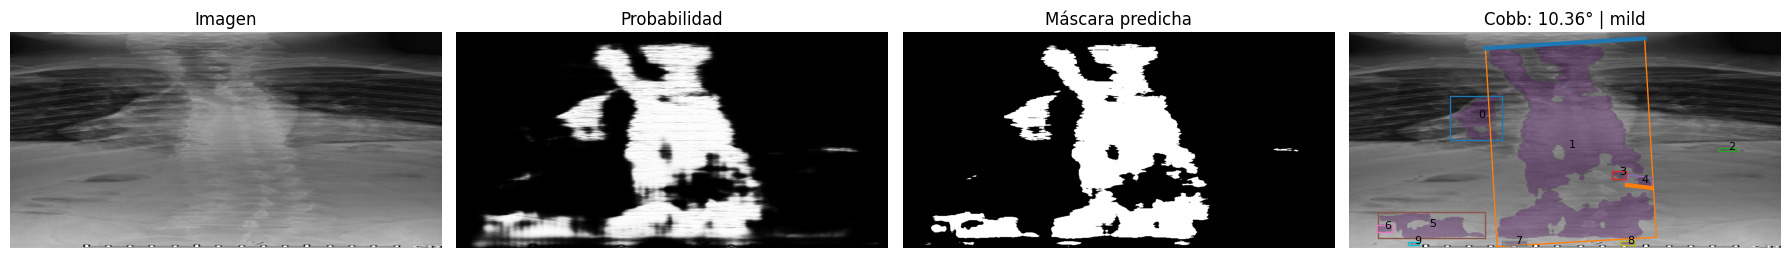

In [19]:
def visualize_cobb_postprocessing(
    image_np,
    binary_mask,
    prob_mask,
    post_result,
    figsize=(18, 5),
):
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    axes[0].imshow(image_np, cmap="gray")
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(prob_mask, cmap="gray")
    axes[1].set_title("Probabilidad")
    axes[1].axis("off")

    axes[2].imshow(binary_mask, cmap="gray")
    axes[2].set_title("Máscara predicha")
    axes[2].axis("off")

    axes[3].imshow(image_np, cmap="gray")

    mask_overlay = np.ma.masked_where(binary_mask == 0, binary_mask)
    axes[3].imshow(mask_overlay, alpha=0.35)

    vertebrae = post_result.get("vertebrae", [])

    for v in vertebrae:
        if "box_points" not in v:
            continue

        box = v["box_points"]
        box_closed = np.vstack([box, box[0]])

        axes[3].plot(box_closed[:, 0], box_closed[:, 1], linewidth=1)

        cx, cy = v["centroid"]
        axes[3].text(cx, cy, str(v["index"]), fontsize=8)

    if post_result["success"]:
        upper = post_result["result"]["upper"]
        lower = post_result["result"]["lower"]

        for edge in [upper["top_edge"], lower["bottom_edge"]]:
            p1, p2 = edge
            axes[3].plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=3,
            )

        title = (
            f"Cobb: {post_result['cobb_angle']:.2f}° | "
            f"{post_result['severity']}"
        )
    else:
        title = "Postprocesamiento fallido"

    axes[3].set_title(title)
    axes[3].axis("off")

    plt.tight_layout()
    return fig


image_np = sample["image"].squeeze().cpu().numpy()

fig = visualize_cobb_postprocessing(
    image_np=image_np,
    binary_mask=pred_mask,
    prob_mask=prob_mask,
    post_result=post_result,
)

plt.show()


## 10. Generar visualizaciones por fold y subirlas a Databricks artifacts

Esto crea un nuevo run de MLflow dedicado a inferencia + postprocesamiento.


In [20]:
@torch.no_grad()
def save_postprocessed_prediction_visualizations(
    model,
    dataset,
    device,
    save_dir,
    fold,
    config,
    num_samples=4,
):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    sample_indices = np.linspace(
        0,
        len(dataset) - 1,
        min(num_samples, len(dataset)),
        dtype=int,
    )

    rows = []
    saved_paths = []

    for i, idx in enumerate(sample_indices):
        sample = dataset[idx]

        pred_mask, prob_mask, post_result = run_inference_with_postprocessing(
            model=model,
            sample=sample,
            device=device,
            config=config,
        )

        image_np = sample["image"].squeeze().cpu().numpy()

        fig = visualize_cobb_postprocessing(
            image_np=image_np,
            binary_mask=pred_mask,
            prob_mask=prob_mask,
            post_result=post_result,
        )

        output_path = os.path.join(
            save_dir,
            f"fold_{fold}_sample_{i}_idx_{idx}_postprocessed.png",
        )

        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

        saved_paths.append(output_path)

        rows.append({
            "fold": fold,
            "sample_idx": int(idx),
            "image_path": sample["image_path"],
            "success": post_result["success"],
            "num_components": post_result["num_components"],
            "cobb_angle": post_result["cobb_angle"],
            "severity": post_result["severity"],
            "is_scoliotic": post_result["is_scoliotic"],
            "visualization_path": output_path,
        })

    results_df = pd.DataFrame(rows)
    results_path = os.path.join(save_dir, f"fold_{fold}_postprocessing_results.csv")
    results_df.to_csv(results_path, index=False)

    return saved_paths, results_path, results_df


In [21]:
df_input.columns

Index(['grupo', 'imagen', 'id_paciente', 'ruta_radiografia',
       'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png',
       'ruta_mascara_multiclase_grises_jpg',
       'ruta_mascara_multiclase_color_jpg', 'metricas_json'],
      dtype='object')

In [22]:
def log_postprocessed_visualizations_to_databricks(
    model,
    summary_df_b,
    df_input,
    base_dir,
    output_root,
    config,
    device,
    num_samples=4,
    experiment_name=MLFLOW_EXPERIMENT_NAME,
):

    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        raise ValueError(f"No se encontró el experimento: {experiment_name}")

    experiment_id = experiment.experiment_id
    run_name = f"{config['run_name']}_inference_postprocessing_artifacts"
    artifact_root = os.path.join(output_root, run_name)
    os.makedirs(artifact_root, exist_ok=True)

    all_results = []

    gkf = GroupKFold(n_splits=config["n_splits"])
    X = df_input["ruta_radiografia"].values
    y = df_input["ruta_mascara_binaria"].values
    groups = df_input["id_paciente"].values

    fold_to_val_df = {}
    for current_fold, (_, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        fold_to_val_df[current_fold] = df_input.iloc[val_idx].reset_index(drop=True)

    with mlflow.start_run(experiment_id=experiment_id,run_name=run_name) as run:
        mlflow.log_params({
            "source_training_run_id": RUN_ID,
            "source_checkpoint_artifact": CHECKPOINT_ARTIFACT_PATH,
            "threshold": config["threshold"],
            "min_area": config["min_area"],
            "min_gap": config["min_gap"],
            "num_samples_per_fold": num_samples,
            "pipeline": "progressive_unet_binary_plus_geometric_postprocessing",
        })

        for _, row in summary_df_b.iterrows():
            fold = int(row["fold"])

            print(f"Procesando fold {fold}")

            val_df = fold_to_val_df[fold]

            dataset = BinarySpineSegmentationDataset(
                val_df,
                base_dir=base_dir,
                img_size=config["img_size"],
            )

            fold_dir = os.path.join(artifact_root, f"fold_{fold}")
            os.makedirs(fold_dir, exist_ok=True)

            _, results_path, results_df = save_postprocessed_prediction_visualizations(
                model=model,
                dataset=dataset,
                device=device,
                save_dir=fold_dir,
                fold=fold,
                config=config,
                num_samples=num_samples,
            )

            all_results.append(results_df)

            mlflow.log_artifacts(
                fold_dir,
                artifact_path=f"fold_{fold}/postprocessed_predictions",
            )

        all_results_df = pd.concat(all_results, ignore_index=True)
        all_results_path = os.path.join(artifact_root, "all_postprocessing_results.csv")
        all_results_df.to_csv(all_results_path, index=False)

        mlflow.log_artifact(
            all_results_path,
            artifact_path="postprocessing_results",
        )

        successful = all_results_df[all_results_df["success"] == True]
        if len(successful) > 0:
            mlflow.log_metric("mean_cobb_angle", float(successful["cobb_angle"].mean()))
            mlflow.log_metric("std_cobb_angle", float(successful["cobb_angle"].std()))
            mlflow.log_metric("mean_num_components", float(successful["num_components"].mean()))
            mlflow.log_metric("success_rate", float(all_results_df["success"].mean()))

        print("Run ID de inferencia/postprocesamiento:", run.info.run_id)

    return all_results_df


# Ejecutar:
# postprocessing_results_df = log_postprocessed_visualizations_to_databricks(
#     model=best_model_b,
#     summary_df_b=summary_df_b_dbx,
#     df_input=df_input,
#     base_dir=BASE_DIR,
#     output_root=MODEL_OUTPUT_DIR,
#     config=EXPERIMENT_B_CONFIG,
#     device=device,
#     num_samples=4,
# )
# display(postprocessing_results_df)


In [23]:
postprocessing_results_df = log_postprocessed_visualizations_to_databricks(
     model=best_model_b,
     summary_df_b=summary_df_b_dbx,
     df_input=df_input,
     base_dir=BASE_DIR,
     output_root=MODEL_OUTPUT_DIR,
     config=EXPERIMENT_B_CONFIG,
     device=device,
     num_samples=4,
 )
display(postprocessing_results_df)

Procesando fold 1
Procesando fold 2
Procesando fold 3
Procesando fold 4
Run ID de inferencia/postprocesamiento: b391fc0b2eba4a80ba6deff5aa3e5c43
🏃 View run exp_b_progressive_unet_binary_paper_like_inference_postprocessing_artifacts at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/2312929421822925/runs/b391fc0b2eba4a80ba6deff5aa3e5c43
🧪 View experiment at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/2312929421822925


,fold,sample_idx,image_path,success,num_components,cobb_angle,severity,is_scoliotic,visualization_path
0,1,0,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,4,56.309933,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
1,1,20,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,14,89.094215,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
2,1,41,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,17,86.616524,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
3,1,62,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,11,69.443947,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
4,2,0,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,10,10.363681,mild,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
5,2,20,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,15,76.632408,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
6,2,41,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,8,59.931408,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
7,2,62,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,5,69.125351,severe,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
8,3,0,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,8,10.120997,mild,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
9,3,20,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,7,29.169109,moderate,True,/content/drive/MyDrive/MasterIA/ProyectoGrado/...


## 11. Registrando pipeline completo como MLflow PyFunc

Esta opción empaqueta **modelo + postprocesamiento** en un modelo MLflow. Para que la  inferencia en Databricks sea directamente:

- `cobb_angle`
- `severity`
- `num_components`
- `is_scoliotic`

El modelo `pyfunc` espera un `pandas.DataFrame` con una columna `image_path`.


In [24]:
# Guardar config como artifact local para el pyfunc
pyfunc_artifact_dir = os.path.join(MODEL_OUTPUT_DIR, "pyfunc_artifacts")
os.makedirs(pyfunc_artifact_dir, exist_ok=True)

pyfunc_config_path = os.path.join(pyfunc_artifact_dir, "inference_config.json")

with open(pyfunc_config_path, "w") as f:
    json.dump(EXPERIMENT_B_CONFIG, f, indent=4)

print("Config pyfunc:", pyfunc_config_path)
print("Checkpoint pyfunc:", local_checkpoint_path)


Config pyfunc: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/progressive_geom/mlflow_outputs/progressive_unet_binary_pipeline/pyfunc_artifacts/inference_config.json
Checkpoint pyfunc: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/progressive_geom/mlflow_outputs/progressive_unet_binary_pipeline/downloaded_databricks_artifacts/best_model_fold_2.pth


In [25]:
class SpineCobbPyFuncModel(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        import json
        import cv2
        import numpy as np
        import torch
        import torch.nn as nn
        import torch.nn.functional as F

        self.cv2 = cv2
        self.np = np
        self.torch = torch
        self.F = F

        config_path = context.artifacts["config"]
        checkpoint_path = context.artifacts["checkpoint"]

        with open(config_path, "r") as f:
            self.config = json.load(f)

        # json convierte tuplas en listas
        self.config["img_size"] = tuple(self.config["img_size"])

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = ProgressiveUNetBinaryPaperLike(
            in_channels=self.config["in_channels"],
            out_channels=self.config["out_channels"],
            base_channels=self.config["base_channels"],
            dropout=self.config["dropout"],
        ).to(self.device)

        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.model.eval()

    def _load_image(self, image_path):
        image = self.cv2.imread(image_path, self.cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"No se pudo cargar la imagen: {image_path}")

        image = self.cv2.resize(
            image,
            self.config["img_size"],
            interpolation=self.cv2.INTER_AREA,
        )

        image = image.astype(self.np.float32) / 255.0
        image = self.np.expand_dims(image, axis=0)
        image = self.np.expand_dims(image, axis=0)

        return self.torch.tensor(image, dtype=self.torch.float32).to(self.device)

    def predict(self, context, model_input):
        rows = []

        for _, row in model_input.iterrows():
            image_path = row["image_path"]

            x = self._load_image(image_path)

            with self.torch.no_grad():
                logits = self.model(x)
                prob = self.torch.sigmoid(logits)
                pred = (prob >= self.config["threshold"]).float()

            pred_mask = pred.squeeze().cpu().numpy().astype(self.np.uint8)

            post_result = postprocess_binary_spine_mask(
                binary_mask=pred_mask,
                min_area=self.config["min_area"],
                min_gap=self.config["min_gap"],
            )

            rows.append({
                "image_path": image_path,
                "success": post_result["success"],
                "num_components": post_result["num_components"],
                "cobb_angle": post_result["cobb_angle"],
                "severity": post_result["severity"],
                "is_scoliotic": post_result["is_scoliotic"],
            })

        return pd.DataFrame(rows)


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [26]:
# Probar input example
input_example = pd.DataFrame({
    "image_path": [dataset_b_val[0]["image_path"]]
})

input_example


,image_path
0,/content/drive/MyDrive/MasterIA/ProyectoGrado/...


In [27]:
# Loggear el pipeline completo como MLflow PyFunc.
# Nota: para serving real en Databricks, las imágenes deben ser accesibles desde el entorno de serving,
# o debes adaptar el pyfunc para recibir la imagen codificada/base64.

PYFUNC_RUN_NAME = f"{EXPERIMENT_B_CONFIG['run_name']}_pyfunc_cobb_pipeline"

source_run = client.get_run(RUN_ID)
source_experiment_id = source_run.info.experiment_id

with mlflow.start_run(experiment_id= source_experiment_id,run_name=PYFUNC_RUN_NAME) as run:
    mlflow.log_params({
        "source_training_run_id": RUN_ID,
        "source_checkpoint_artifact": CHECKPOINT_ARTIFACT_PATH,
        "pipeline": "progressive_unet_binary_plus_geometric_postprocessing_pyfunc",
    })

    model_info = mlflow.pyfunc.log_model(
        name="spine_cobb_pipeline",
        python_model=SpineCobbPyFuncModel(),
        artifacts={
            "checkpoint": local_checkpoint_path,
            "config": pyfunc_config_path,
        },
        input_example=input_example,
        pip_requirements=[
            "mlflow",
            "torch",
            "opencv-python-headless",
            "numpy",
            "pandas",
        ],
    )

    print("Run ID:", run.info.run_id)
    print("Model URI:", model_info.model_uri)


2026/05/18 21:15:57 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/05/18 21:15:57 INFO mlflow.pyfunc: Inferring model signature from input example
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64)

Run ID: 56da3b9ebc754fa0a8a3619603f02f59
Model URI: models:/m-4096e25d64cf4074ac9e9588f6962625
🏃 View run exp_b_progressive_unet_binary_paper_like_pyfunc_cobb_pipeline at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/2312929421822925/runs/56da3b9ebc754fa0a8a3619603f02f59
🧪 View experiment at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/2312929421822925


## 12. Registrar en Unity Catalog

Ajustamos `UC_MODEL_NAME` al formato de tres niveles:

`workspace.default.spine_cobb_pipeline` para guardarlo consistentemente en databricks


In [28]:
# Registrar el pipeline pyfunc en Unity Catalog
# Revisar permisos sobre el catalog y schema.

mlflow.set_registry_uri("databricks-uc")
UC_MODEL_NAME = "workspace.default.spine_cobb_pipeline"

registered_model = mlflow.register_model(
     model_uri=model_info.model_uri,
     name=UC_MODEL_NAME,
 )

print("Registered model:", UC_MODEL_NAME)
print("Version:", registered_model.version)


Registered model 'workspace.default.spine_cobb_pipeline' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/10 [00:00<?, ?it/s]

Created version '4' of model 'workspace.default.spine_cobb_pipeline'.


Registered model: workspace.default.spine_cobb_pipeline
Version: 4


## 13. Cargar el PyFunc y probar inferencia

Esta prueba carga el pipeline como modelo MLflow y ejecuta inferencia con postprocesamiento.


In [29]:
loaded_pipeline = mlflow.pyfunc.load_model(model_info.model_uri)

pred_df = loaded_pipeline.predict(input_example)
display(pred_df)


,image_path,success,num_components,cobb_angle,severity,is_scoliotic
0,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,True,10,10.363681,mild,True


In [70]:
model_info.model_uri

'models:/m-4096e25d64cf4074ac9e9588f6962625'

## Notas importantes para Databricks Model Serving

- Guardar visualizaciones como artifacts es ideal para análisis, informe y comparación cualitativa.
- Para inferencia automatizada con postprocesamiento, conviene registrar un modelo `pyfunc`, porque permite incluir lógica personalizada antes/después del modelo.
- Para servirlo como endpoint, lo más robusto es que el pyfunc reciba imagen en base64 o una ruta accesible por el entorno de serving.


# 2. Experimento C- Adaptación de la red Progressive-Unet del paper al problema multiclase

In [30]:
print(MLFLOW_EXPERIMENT_NAME)

/Users/sl.lancheros20@uniandes.edu.co/spine_segmentation_progressive_unet


In [31]:
EXPERIMENT_C_CONFIG = {
    "experiment_name": MLFLOW_EXPERIMENT_NAME+"_exp_c",
    "run_name": "experiment_c_progressive_unet_multiclass_vertebrae",

    "model_type": "ProgressiveUNetMulticlassPaperLike",
    "task": "multiclass_vertebra_segmentation",

    "img_size": (256, 256),
    "in_channels": 1,
    "num_classes": 18,

    "batch_size": 2,
    "num_epochs": 60,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "patience": 12,

    "ce_weight": 0.5,
    "dice_weight": 0.5,

    "base_channels": 32,
    "dropout": 0.0,
    "n_splits": 4,
    "seed": 42,
}

In [32]:
print(df_input.columns.tolist())
display(df_input.head().T)

['grupo', 'imagen', 'id_paciente', 'ruta_radiografia', 'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png', 'ruta_mascara_multiclase_grises_jpg', 'ruta_mascara_multiclase_color_jpg', 'metricas_json']


,0,1,2,3,4
grupo,Normal,Normal,Normal,Normal,Normal
imagen,N_1.jpg,N_2.jpg,N_3.jpg,N_4.jpg,N_5.jpg
id_paciente,1,2,3,4,5
ruta_radiografia,Normal/N_1.jpg,Normal/N_2.jpg,Normal/N_3.jpg,Normal/N_4.jpg,Normal/N_5.jpg
ruta_mascara_binaria,LabelBinaryJPG/Label_N_1.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelBinaryJPG/Label_N_5.jpg
ruta_mascara_multiclase_id_png,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_ID_PNG/LabelMulti_N_5.png
ruta_mascara_multiclase_grises_jpg,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg
ruta_mascara_multiclase_color_jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg
metricas_json,NaN,NaN,NaN,NaN,NaN


## Dataset

In [33]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset


class MulticlassSpineSegmentationDataset(Dataset):
    def __init__(
        self,
        df,
        base_dir,
        img_size=(256, 256),
        image_col="ruta_radiografia",
        mask_col="ruta_mascara_multiclase_id_png",
        num_classes=18,
    ):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.img_size = img_size
        self.image_col = image_col
        self.mask_col = mask_col
        self.num_classes = num_classes

    def _resolve_path(self, path):
        path = str(path)


        if os.path.isabs(path):
            return path

        return os.path.join(self.base_dir, path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self._resolve_path(row[self.image_col])
        mask_path = self._resolve_path(row[self.mask_col])

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if image is None:
            raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")

        if mask is None:
            raise FileNotFoundError(f"No se pudo leer la máscara: {mask_path}")

        # Si la máscara viene con 3 canales, tomar un canal.
        # Para LabelMultiClass_ID_PNG idealmente debería venir en escala de grises/id.
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]

        image = cv2.resize(
            image,
            self.img_size,
            interpolation=cv2.INTER_AREA
        )

        mask = cv2.resize(
            mask,
            self.img_size,
            interpolation=cv2.INTER_NEAREST
        )

        unique_values = np.unique(mask)

        if unique_values.max() >= self.num_classes:
            raise ValueError(
                f"La máscara tiene valores fuera de rango: {unique_values}. "
                f"num_classes={self.num_classes}. Usar LabelMultiClass_ID_PNG."
            )

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.int64)

        image_tensor = torch.from_numpy(image).unsqueeze(0)  # [1, H, W]
        mask_tensor = torch.from_numpy(mask)                 # [H, W]

        return image_tensor, mask_tensor

Probando que uso los nombres de columna bien

In [34]:
IMAGE_COL = "ruta_radiografia"
MASK_COL = "ruta_mascara_multiclase_id_png"
GROUP_COL = "id_paciente"

dataset_test = MulticlassSpineSegmentationDataset(
    df=df_input,
    base_dir=BASE_DIR,
    img_size=EXPERIMENT_C_CONFIG["img_size"],
    image_col=IMAGE_COL,
    mask_col=MASK_COL,
    num_classes=EXPERIMENT_C_CONFIG["num_classes"],
)

image, mask = dataset_test[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", torch.unique(mask))

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([256, 256])
Mask unique values: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])


## Implementación Ajustes Modelo Progressive UNet Multiclase

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# BLOQUE DOBLE CONVOLUCIÓN
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]

        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# ============================================================
# BLOQUE DOWN
# ============================================================

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels, dropout=dropout)
        )

    def forward(self, x):
        return self.block(x)


# ============================================================
# BLOQUE UP
# ============================================================

class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.0):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels=out_channels + skip_channels,
            out_channels=out_channels,
            dropout=dropout
        )

    def forward(self, x, skip):
        x = self.up(x)

        # Ajuste de tamaño por seguridad si hay diferencias por redondeos
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)

        return x


# ============================================================
# PROGRESSIVE U-NET MULTICLASE
# ============================================================

class ProgressiveUNetMulticlassPaperLike(nn.Module):
    def __init__(
        self,
        in_channels=1,
        num_classes=18,
        base_channels=32,
        dropout=0.0,
        deep_supervision=True
    ):
        """
        Progressive U-Net adaptada a segmentación multiclase.

        Parámetros
        ----------
        in_channels : int
            Número de canales de entrada. Para radiografía en gris: 1.

        num_classes : int
            Número de clases de salida.

                0  = background
                1  = T1
                ...
                17 = L5

        base_channels : int
            Número base de filtros.

        dropout : float
            Dropout opcional.

        deep_supervision : bool
            Si True, devuelve varias salidas progresivas del decoder.
            Si False, devuelve solo la salida final.
        """

        super().__init__()

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.base_channels = base_channels
        self.deep_supervision = deep_supervision

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8
        c5 = base_channels * 16

        # -----------------------------
        # Encoder
        # -----------------------------
        self.enc1 = DoubleConv(in_channels, c1, dropout=dropout)
        self.enc2 = DownBlock(c1, c2, dropout=dropout)
        self.enc3 = DownBlock(c2, c3, dropout=dropout)
        self.enc4 = DownBlock(c3, c4, dropout=dropout)

        # -----------------------------
        # Bottleneck
        # -----------------------------
        self.bottleneck = DownBlock(c4, c5, dropout=dropout)

        # -----------------------------
        # Decoder progresivo
        # -----------------------------
        self.up4 = UpBlock(c5, c4, c4, dropout=dropout)
        self.up3 = UpBlock(c4, c3, c3, dropout=dropout)
        self.up2 = UpBlock(c3, c2, c2, dropout=dropout)
        self.up1 = UpBlock(c2, c1, c1, dropout=dropout)

        # -----------------------------
        # Cabezas de salida progresivas
        # Todas producen num_classes canales
        # -----------------------------
        self.out_d4 = nn.Conv2d(c4, num_classes, kernel_size=1)
        self.out_d3 = nn.Conv2d(c3, num_classes, kernel_size=1)
        self.out_d2 = nn.Conv2d(c2, num_classes, kernel_size=1)
        self.out_final = nn.Conv2d(c1, num_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]

        # -----------------------------
        # Encoder
        # -----------------------------
        e1 = self.enc1(x)        # [B, c1, H, W]
        e2 = self.enc2(e1)       # [B, c2, H/2, W/2]
        e3 = self.enc3(e2)       # [B, c3, H/4, W/4]
        e4 = self.enc4(e3)       # [B, c4, H/8, W/8]

        # -----------------------------
        # Bottleneck
        # -----------------------------
        b = self.bottleneck(e4)  # [B, c5, H/16, W/16]

        # -----------------------------
        # Decoder
        # -----------------------------
        d4 = self.up4(b, e4)     # [B, c4, H/8, W/8]
        d3 = self.up3(d4, e3)    # [B, c3, H/4, W/4]
        d2 = self.up2(d3, e2)    # [B, c2, H/2, W/2]
        d1 = self.up1(d2, e1)    # [B, c1, H, W]

        # -----------------------------
        # Salidas progresivas
        # -----------------------------
        out_d4 = self.out_d4(d4)
        out_d3 = self.out_d3(d3)
        out_d2 = self.out_d2(d2)
        out_final = self.out_final(d1)

        # Ajustar todas las salidas al tamaño original
        out_d4 = F.interpolate(
            out_d4,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        out_d3 = F.interpolate(
            out_d3,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        out_d2 = F.interpolate(
            out_d2,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        if self.deep_supervision:
            return [out_d4, out_d3, out_d2, out_final]

        return out_final

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MulticlassDiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6, include_background=False):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.include_background = include_background

    def forward(self, logits, targets):
        """
        logits:  [B, C, H, W]
        targets: [B, H, W]
        """
        probs = torch.softmax(logits, dim=1)

        targets_one_hot = F.one_hot(
            targets.long(),
            num_classes=self.num_classes
        )

        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()

        if not self.include_background:
            probs = probs[:, 1:, :, :]
            targets_one_hot = targets_one_hot[:, 1:, :, :]

        dims = (0, 2, 3)

        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)

        dice = (2.0 * intersection + self.smooth) / (
            cardinality + self.smooth
        )

        return 1.0 - dice.mean()


class CombinedMulticlassLoss(nn.Module):
    def __init__(
        self,
        num_classes,
        ce_weight=0.4,
        dice_weight=0.6,
        include_background_dice=False,
        class_weights=None,
    ):
        super().__init__()

        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

        if class_weights is not None:
            class_weights = torch.tensor(class_weights, dtype=torch.float32)

        self.register_buffer("class_weights", class_weights)

        self.dice = MulticlassDiceLoss(
            num_classes=num_classes,
            include_background=include_background_dice
        )

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets.long(),
            weight=self.class_weights
        )

        dice_loss = self.dice(logits, targets.long())

        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

Agregando manejo de varias salidas de Progresive UNet

In [37]:
def compute_progressive_multiclass_loss(outputs, targets, criterion):
    """
    outputs puede ser:
    - Tensor [B, C, H, W]
    - list/tuple de tensores [B, C, H, W]
    """

    if isinstance(outputs, (list, tuple)):
        weights = torch.linspace(
            0.4,
            1.0,
            steps=len(outputs),
            device=targets.device
        )

        weights = weights / weights.sum()

        total_loss = 0.0

        for output, weight in zip(outputs, weights):
            if output.shape[-2:] != targets.shape[-2:]:
                output = F.interpolate(
                    output,
                    size=targets.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

            total_loss = total_loss + weight * criterion(output, targets)

        final_logits = outputs[-1]

        if final_logits.shape[-2:] != targets.shape[-2:]:
            final_logits = F.interpolate(
                final_logits,
                size=targets.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        return total_loss, final_logits

    else:
        logits = outputs

        if logits.shape[-2:] != targets.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=targets.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        loss = criterion(logits, targets)

        return loss, logits

## Métricas Multiclase

In [38]:
def compute_multiclass_metrics(logits, targets, num_classes=18, include_background=False):
    """
    logits:  [B, C, H, W]
    targets: [B, H, W]
    """

    preds = torch.argmax(logits, dim=1)

    start_class = 0 if include_background else 1

    dice_scores = []
    iou_scores = []

    per_class = {}

    for cls in range(start_class, num_classes):
        pred_cls = preds == cls
        target_cls = targets == cls

        intersection = (pred_cls & target_cls).sum().float()
        pred_sum = pred_cls.sum().float()
        target_sum = target_cls.sum().float()
        union = (pred_cls | target_cls).sum().float()

        # Solo calcular clases presentes en target o predicción
        if target_sum.item() == 0 and pred_sum.item() == 0:
            continue

        dice = (2 * intersection + 1e-6) / (pred_sum + target_sum + 1e-6)
        iou = (intersection + 1e-6) / (union + 1e-6)

        dice_scores.append(dice)
        iou_scores.append(iou)

        per_class[f"class_{cls}_dice"] = dice.item()
        per_class[f"class_{cls}_iou"] = iou.item()

    if len(dice_scores) == 0:
        mean_dice = torch.tensor(0.0, device=targets.device)
        mean_iou = torch.tensor(0.0, device=targets.device)
    else:
        mean_dice = torch.stack(dice_scores).mean()
        mean_iou = torch.stack(iou_scores).mean()

    pixel_acc = (preds == targets).float().mean()

    return {
        "dice": mean_dice.item(),
        "iou": mean_iou.item(),
        "pixel_acc": pixel_acc.item(),
        **per_class
    }

## Entrenamiento de un Fold

In [39]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import copy
import pandas as pd
import os
import mlflow


def train_one_fold_progressive_unet_multiclass(
    fold,
    train_df,
    val_df,
    base_dir,
    config,
    device,
    output_root,
    image_col,
    mask_col,
    log_to_mlflow=True,
):
    print(f"\n========== EXPERIMENTO C MULTICLASE | Fold {fold} ==========")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))

    fold_dir = os.path.join(output_root, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    train_dataset = MulticlassSpineSegmentationDataset(
        df=train_df,
        base_dir=base_dir,
        img_size=config["img_size"],
        image_col=image_col,
        mask_col=mask_col,
        num_classes=config["num_classes"],
    )

    val_dataset = MulticlassSpineSegmentationDataset(
        df=val_df,
        base_dir=base_dir,
        img_size=config["img_size"],
        image_col=image_col,
        mask_col=mask_col,
        num_classes=config["num_classes"],
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    model = ProgressiveUNetMulticlassPaperLike(
        in_channels=config["in_channels"],
        num_classes=config["num_classes"],
        base_channels=config["base_channels"],
    ).to(device)

    criterion = CombinedMulticlassLoss(
        num_classes=config["num_classes"],
        ce_weight=config["ce_weight"],
        dice_weight=config["dice_weight"],
        include_background_dice=False,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    best_val_dice = -1.0
    best_epoch = -1
    best_model_state = None
    patience_counter = 0

    history = []

    for epoch in range(config["num_epochs"]):
        model.train()

        train_loss_total = 0.0
        train_dice_total = 0.0
        train_iou_total = 0.0
        train_acc_total = 0.0

        for images, masks in tqdm(train_loader, desc=f"Fold {fold} Epoch {epoch+1} Train"):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)

            loss, logits = compute_progressive_multiclass_loss(
                outputs=outputs,
                targets=masks,
                criterion=criterion
            )

            loss.backward()
            optimizer.step()

            metrics = compute_multiclass_metrics(
                logits=logits.detach(),
                targets=masks,
                num_classes=config["num_classes"],
                include_background=False
            )

            train_loss_total += loss.item()
            train_dice_total += metrics["dice"]
            train_iou_total += metrics["iou"]
            train_acc_total += metrics["pixel_acc"]

        train_loss = train_loss_total / len(train_loader)
        train_dice = train_dice_total / len(train_loader)
        train_iou = train_iou_total / len(train_loader)
        train_acc = train_acc_total / len(train_loader)

        model.eval()

        val_loss_total = 0.0
        val_dice_total = 0.0
        val_iou_total = 0.0
        val_acc_total = 0.0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Fold {fold} Epoch {epoch+1} Val"):
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                outputs = model(images)

                loss, logits = compute_progressive_multiclass_loss(
                    outputs=outputs,
                    targets=masks,
                    criterion=criterion
                )

                metrics = compute_multiclass_metrics(
                    logits=logits,
                    targets=masks,
                    num_classes=config["num_classes"],
                    include_background=False
                )

                val_loss_total += loss.item()
                val_dice_total += metrics["dice"]
                val_iou_total += metrics["iou"]
                val_acc_total += metrics["pixel_acc"]

        val_loss = val_loss_total / len(val_loader)
        val_dice = val_dice_total / len(val_loader)
        val_iou = val_iou_total / len(val_loader)
        val_acc = val_acc_total / len(val_loader)

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "train_pixel_acc": train_acc,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "val_pixel_acc": val_acc,
        }

        history.append(row)

        print(
            f"Epoch {epoch+1:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_dice={train_dice:.4f} | "
            f"val_dice={val_dice:.4f} | "
            f"val_iou={val_iou:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if log_to_mlflow:
            mlflow.log_metric(f"fold_{fold}/train_loss", train_loss, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_loss", val_loss, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/train_dice", train_dice, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_dice", val_dice, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/train_iou", train_iou, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_iou", val_iou, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_pixel_acc", val_acc, step=epoch + 1)

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            checkpoint_path = os.path.join(
                fold_dir,
                f"best_model_fold_{fold}.pth"
            )

            torch.save(
                {
                    "fold": fold,
                    "epoch": best_epoch,
                    "model_state_dict": best_model_state,
                    "best_val_dice": best_val_dice,
                    "config": config,
                },
                checkpoint_path
            )

            if log_to_mlflow:
                mlflow.log_artifact(
                    checkpoint_path,
                    artifact_path=f"checkpoints/fold_{fold}"
                )

            print(f"Nuevo mejor modelo Fold {fold}: val_dice={best_val_dice:.4f}")

        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print(f"Early stopping en epoch {epoch+1}")
            break

    history_df = pd.DataFrame(history)

    history_path = os.path.join(fold_dir, f"history_fold_{fold}.csv")
    history_df.to_csv(history_path, index=False)

    if log_to_mlflow:
        mlflow.log_artifact(
            history_path,
            artifact_path=f"histories/fold_{fold}"
        )

        mlflow.log_metric(f"fold_{fold}/best_val_dice", best_val_dice)
        mlflow.log_metric(f"fold_{fold}/best_epoch", best_epoch)

    summary = {
        "fold": fold,
        "best_val_dice": best_val_dice,
        "best_epoch": best_epoch,
        "checkpoint_path": checkpoint_path,
    }

    return history_df, summary

## Run experiment

In [40]:
from sklearn.model_selection import GroupKFold
import numpy as np
import mlflow
import os


def run_experiment_c_progressive_unet_multiclass(
    df_input,
    base_dir,
    output_root,
    config,
    image_col,
    mask_col,
    group_col="patient_id",
    device="cuda",
):
    os.makedirs(output_root, exist_ok=True)

    mlflow.set_tracking_uri("databricks")
    experiment = mlflow.set_experiment(config["experiment_name"])

    all_histories = []
    summaries = []

    gkf = GroupKFold(n_splits=config["n_splits"])

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=config["run_name"]
    ) as run:

        print("Run ID:", run.info.run_id)
        print("Experiment ID:", run.info.experiment_id)

        mlflow.log_params(config)
        mlflow.log_param("image_col", image_col)
        mlflow.log_param("mask_col", mask_col)
        mlflow.log_param("group_col", group_col)

        for fold, (train_idx, val_idx) in enumerate(
            gkf.split(df_input, groups=df_input[group_col]),
            start=1
        ):
            train_df = df_input.iloc[train_idx].reset_index(drop=True)
            val_df = df_input.iloc[val_idx].reset_index(drop=True)

            train_patients = set(train_df[group_col].unique())
            val_patients = set(val_df[group_col].unique())
            overlap = train_patients.intersection(val_patients)

            print(f"\nFold {fold}")
            print("Train samples:", len(train_df))
            print("Val samples:", len(val_df))
            print("Patient overlap:", len(overlap))

            history_df, summary = train_one_fold_progressive_unet_multiclass(
                fold=fold,
                train_df=train_df,
                val_df=val_df,
                base_dir=base_dir,
                config=config,
                device=device,
                output_root=output_root,
                image_col=image_col,
                mask_col=mask_col,
                log_to_mlflow=True,
            )

            history_df["run_id"] = run.info.run_id
            history_df["experiment"] = config["run_name"]

            all_histories.append(history_df)
            summaries.append(summary)

        histories_df = pd.concat(all_histories, ignore_index=True)
        summary_df = pd.DataFrame(summaries)

        mean_best_val_dice = summary_df["best_val_dice"].mean()
        std_best_val_dice = summary_df["best_val_dice"].std()

        mlflow.log_metric("mean_best_val_dice", mean_best_val_dice)
        mlflow.log_metric("std_best_val_dice", std_best_val_dice)

        histories_path = os.path.join(output_root, "experiment_c_histories.csv")
        summary_path = os.path.join(output_root, "experiment_c_summary.csv")

        histories_df.to_csv(histories_path, index=False)
        summary_df.to_csv(summary_path, index=False)

        mlflow.log_artifact(histories_path, artifact_path="results")
        mlflow.log_artifact(summary_path, artifact_path="results")

        print("\nResumen Experimento C")
        print(summary_df)
        print("Mean best val dice:", mean_best_val_dice)
        print("Std best val dice:", std_best_val_dice)

    return histories_df, summary_df

## Entrenamiento del modelo

In [41]:
df_input.columns

Index(['grupo', 'imagen', 'id_paciente', 'ruta_radiografia',
       'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png',
       'ruta_mascara_multiclase_grises_jpg',
       'ruta_mascara_multiclase_color_jpg', 'metricas_json'],
      dtype='object')

In [42]:
df_input= df_input[~df_input["ruta_radiografia"].str.contains("S_107.jpg")]

In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

OUTPUT_ROOT = "/content/drive/MyDrive/MasterIA/ProyectoGrado/mlflow_outputs/experiment_c_progressive_unet_multiclass"

IMAGE_COL = "ruta_radiografia"
MASK_COL = "ruta_mascara_multiclase_id_png"
GROUP_COL = "id_paciente"

histories_df_c, summary_df_c = run_experiment_c_progressive_unet_multiclass(
    df_input=df_input,
    base_dir=BASE_DIR,
    output_root=OUTPUT_ROOT,
    config=EXPERIMENT_C_CONFIG,
    image_col=IMAGE_COL,
    mask_col=MASK_COL,
    group_col=GROUP_COL,
    device=DEVICE,
)

display(summary_df_c)

# Experimento C- Transfer Learning

In [44]:
import time

In [45]:
timestamp = time.strftime("%Y%m%d-%H%M%S")

In [69]:
EXPERIMENT_C_TRANSFER_CONFIG = {
    "experiment_name": MLFLOW_EXPERIMENT_NAME+f"_exp_c_transfer_learning_{timestamp}",
    "run_name": "experiment_c_progressive_unet_multiclass_vertebrae",
    "run_name": "experiment_c_progressive_unet_multiclass_transfer",

    "model_type": "ProgressiveUNetMulticlassPaperLike",
    "task": "multiclass_vertebra_segmentation_with_partial_transfer",

    "img_size": (256, 256),
    "in_channels": 1,
    "num_classes": 18,

    "batch_size": 2,
    "num_epochs": 50,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "patience": 10,

    "ce_weight": 0.5,
    "dice_weight": 0.5,

    "base_channels": 32,
    "dropout": 0.0,
    "n_splits": 4,
    "seed": 42,

    # Transfer learning parcial
    "use_partial_transfer": True,
    "pretrained_checkpoint_path": "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/best_model_fold_3.pth",
    "freeze_encoder_epochs": 5,
}

## Función para cargar pesos parcialmente

Esta función carga solo las capas que tienen el mismo nombre y la misma forma. Las cabezas de salida binarias se saltan automáticamente porque no coinciden con las de 18 clases.

In [46]:
import torch


def clean_state_dict_keys(state_dict):
    """
    Limpia prefijos como 'module.' si el modelo fue guardado con DataParallel.
    """
    cleaned = {}

    for key, value in state_dict.items():
        new_key = key

        if new_key.startswith("module."):
            new_key = new_key.replace("module.", "", 1)

        cleaned[new_key] = value

    return cleaned


def extract_model_state_dict(checkpoint):
    """
    Soporta varios formatos de checkpoint:
    - state_dict directo
    - {"model_state_dict": ...}
    - {"state_dict": ...}
    """
    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            return checkpoint["model_state_dict"]

        if "state_dict" in checkpoint:
            return checkpoint["state_dict"]

    return checkpoint


def load_partial_weights_from_binary_checkpoint(
    model,
    checkpoint_path,
    device="cpu",
    verbose=True
):
    """
    Carga pesos compatibles desde un checkpoint binario hacia un modelo multiclase.

    Carga:
    - encoder compatible
    - bottleneck compatible
    - decoder compatible

    Omite:
    - capas finales / cabezas de salida con shape diferente
    """

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    pretrained_state = extract_model_state_dict(checkpoint)
    pretrained_state = clean_state_dict_keys(pretrained_state)

    current_state = model.state_dict()

    loaded_keys = []
    skipped_keys = []

    compatible_state = {}

    for key, pretrained_value in pretrained_state.items():
        if key in current_state:
            current_value = current_state[key]

            if pretrained_value.shape == current_value.shape:
                compatible_state[key] = pretrained_value
                loaded_keys.append(key)
            else:
                skipped_keys.append(
                    {
                        "key": key,
                        "reason": "shape_mismatch",
                        "pretrained_shape": tuple(pretrained_value.shape),
                        "current_shape": tuple(current_value.shape),
                    }
                )
        else:
            skipped_keys.append(
                {
                    "key": key,
                    "reason": "key_not_found_in_current_model",
                    "pretrained_shape": tuple(pretrained_value.shape),
                    "current_shape": None,
                }
            )

    current_state.update(compatible_state)
    model.load_state_dict(current_state)

    report = {
        "checkpoint_path": checkpoint_path,
        "num_loaded_layers": len(loaded_keys),
        "num_skipped_layers": len(skipped_keys),
        "loaded_keys": loaded_keys,
        "skipped_keys": skipped_keys,
    }

    if verbose:
        print("Transfer learning parcial completado.")
        print("Checkpoint:", checkpoint_path)
        print("Capas cargadas:", len(loaded_keys))
        print("Capas omitidas:", len(skipped_keys))

        print("\nPrimeras capas cargadas:")
        for key in loaded_keys[:15]:
            print("  +", key)

        print("\nCapas omitidas:")
        for item in skipped_keys[:20]:
            print(
                "  -",
                item["key"],
                "|",
                item["reason"],
                "| pretrained:",
                item["pretrained_shape"],
                "| current:",
                item["current_shape"],
            )

    return model, report

## Funciones para congelar y descongelar encoder

Para evitar que el modelo olvide rápido lo aprendido en el binario, estas funciones permiten congelar el encoder unas pocas épocas.

In [68]:
def set_encoder_trainable(model, trainable=True):
    """
    Congela o descongela encoder + bottleneck.
    Mantiene decoder y cabezas de salida entrenables.
    """

    encoder_module_names = [
        "enc1",
        "enc2",
        "enc3",
        "enc4",
        "bottleneck",
    ]

    for name, module in model.named_children():
        if name in encoder_module_names:
            for param in module.parameters():
                param.requires_grad = trainable


def print_trainable_parameters(model):
    total_params = 0
    trainable_params = 0

    for param in model.parameters():
        total_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

## Train one fold actualizado

In [48]:
import os
import json
import copy
import torch
import mlflow
import pandas as pd

from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def get_pretrained_checkpoint_for_fold(config, fold):
    """
    Permite usar:
    1. Un checkpoint único:
       config["pretrained_checkpoint_path"]

    2. Un checkpoint por fold:
       config["pretrained_checkpoint_paths"] = {
           1: "...fold_1.pth",
           2: "...fold_2.pth",
           3: "...fold_3.pth",
           4: "...fold_4.pth",
       }

    Recomendado: usar checkpoint por fold para evitar leakage.
    """

    if "pretrained_checkpoint_paths" in config:
        paths = config["pretrained_checkpoint_paths"]

        if fold not in paths:
            raise ValueError(
                f"No encontré checkpoint preentrenado para fold {fold}. "
                f"Revisa config['pretrained_checkpoint_paths']."
            )

        return paths[fold]

    if "pretrained_checkpoint_path" in config:
        return config["pretrained_checkpoint_path"]

    raise ValueError(
        "Falta definir 'pretrained_checkpoint_path' o "
        "'pretrained_checkpoint_paths' en config."
    )


def train_one_fold_progressive_unet_multiclass_transfer(
    fold,
    train_df,
    val_df,
    base_dir,
    config,
    device,
    output_root,
    image_col,
    mask_col,
    log_to_mlflow=True,
):
    print(f"\n========== EXPERIMENTO C TRANSFER | Fold {fold} ==========")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))

    fold_dir = os.path.join(output_root, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # ============================================================
    # DATASETS
    # ============================================================

    train_dataset = MulticlassSpineSegmentationDataset(
        df=train_df,
        base_dir=base_dir,
        img_size=config["img_size"],
        image_col=image_col,
        mask_col=mask_col,
        num_classes=config["num_classes"],
    )

    val_dataset = MulticlassSpineSegmentationDataset(
        df=val_df,
        base_dir=base_dir,
        img_size=config["img_size"],
        image_col=image_col,
        mask_col=mask_col,
        num_classes=config["num_classes"],
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config.get("num_workers", 2),
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config.get("num_workers", 2),
        pin_memory=True,
    )

    # ============================================================
    # MODELO MULTICLASE
    # ============================================================

    model = ProgressiveUNetMulticlassPaperLike(
        in_channels=config["in_channels"],
        num_classes=config["num_classes"],
        base_channels=config["base_channels"],
        dropout=config.get("dropout", 0.0),
        deep_supervision=config.get("deep_supervision", True),
    ).to(device)

    # ============================================================
    # TRANSFER LEARNING PARCIAL DESDE MODELO BINARIO
    # ============================================================

    transfer_report = None

    if config.get("use_partial_transfer", False):
        pretrained_checkpoint_path = get_pretrained_checkpoint_for_fold(
            config=config,
            fold=fold
        )

        print("\nCargando transfer learning parcial desde:")
        print(pretrained_checkpoint_path)

        model, transfer_report = load_partial_weights_from_binary_checkpoint(
            model=model,
            checkpoint_path=pretrained_checkpoint_path,
            device=device,
            verbose=True,
        )

        freeze_encoder_epochs = config.get("freeze_encoder_epochs", 0)

        if freeze_encoder_epochs > 0:
            print(f"\nCongelando encoder durante {freeze_encoder_epochs} épocas.")
            set_encoder_trainable(model, trainable=False)

    print_trainable_parameters(model)

    # ============================================================
    # LOSS Y OPTIMIZER
    # ============================================================

    criterion = CombinedMulticlassLoss(
        num_classes=config["num_classes"],
        ce_weight=config["ce_weight"],
        dice_weight=config["dice_weight"],
        include_background_dice=config.get("include_background_dice", False),
    )

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    # ============================================================
    # LOG TRANSFER REPORT
    # ============================================================

    if log_to_mlflow and transfer_report is not None:
        mlflow.log_param(f"fold_{fold}_transfer_checkpoint_path", transfer_report["checkpoint_path"])
        mlflow.log_param(f"fold_{fold}_transfer_num_loaded_layers", transfer_report["num_loaded_layers"])
        mlflow.log_param(f"fold_{fold}_transfer_num_skipped_layers", transfer_report["num_skipped_layers"])
        mlflow.log_param(f"fold_{fold}_freeze_encoder_epochs", config.get("freeze_encoder_epochs", 0))

        transfer_report_path = os.path.join(
            fold_dir,
            f"transfer_report_fold_{fold}.json"
        )

        with open(transfer_report_path, "w") as f:
            json.dump(transfer_report, f, indent=4)

        mlflow.log_artifact(
            transfer_report_path,
            artifact_path=f"transfer_reports/fold_{fold}"
        )

    # ============================================================
    # ENTRENAMIENTO
    # ============================================================

    best_val_dice = -1.0
    best_epoch = -1
    best_model_state = None
    best_checkpoint_path = None
    patience_counter = 0

    history = []

    freeze_encoder_epochs = config.get("freeze_encoder_epochs", 0)

    for epoch in range(config["num_epochs"]):

        # --------------------------------------------------------
        # DESCONGELAR ENCODER DESPUÉS DE N ÉPOCAS
        # --------------------------------------------------------

        if (
            config.get("use_partial_transfer", False)
            and freeze_encoder_epochs > 0
            and epoch == freeze_encoder_epochs
        ):
            print(f"\nDescongelando encoder en epoch {epoch + 1}.")

            set_encoder_trainable(model, trainable=True)
            print_trainable_parameters(model)

            fine_tune_lr = config.get("fine_tune_lr", config["lr"] * 0.5)

            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=fine_tune_lr,
                weight_decay=config["weight_decay"],
            )

            print("Nuevo learning rate para fine-tuning:", fine_tune_lr)

        # ========================================================
        # TRAIN
        # ========================================================

        model.train()

        train_loss_total = 0.0
        train_dice_total = 0.0
        train_iou_total = 0.0
        train_acc_total = 0.0

        train_batches = 0

        for images, masks in tqdm(
            train_loader,
            desc=f"Fold {fold} | Epoch {epoch + 1} | Train"
        ):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)

            loss, logits = compute_progressive_multiclass_loss(
                outputs=outputs,
                targets=masks,
                criterion=criterion,
            )

            loss.backward()
            optimizer.step()

            metrics = compute_multiclass_metrics(
                logits=logits.detach(),
                targets=masks,
                num_classes=config["num_classes"],
                include_background=config.get("include_background_metrics", False),
            )

            train_loss_total += loss.item()
            train_dice_total += metrics["dice"]
            train_iou_total += metrics["iou"]
            train_acc_total += metrics["pixel_acc"]
            train_batches += 1

        train_loss = train_loss_total / max(train_batches, 1)
        train_dice = train_dice_total / max(train_batches, 1)
        train_iou = train_iou_total / max(train_batches, 1)
        train_acc = train_acc_total / max(train_batches, 1)

        # ========================================================
        # VALIDATION
        # ========================================================

        model.eval()

        val_loss_total = 0.0
        val_dice_total = 0.0
        val_iou_total = 0.0
        val_acc_total = 0.0

        val_batches = 0

        with torch.no_grad():
            for images, masks in tqdm(
                val_loader,
                desc=f"Fold {fold} | Epoch {epoch + 1} | Val"
            ):
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                outputs = model(images)

                loss, logits = compute_progressive_multiclass_loss(
                    outputs=outputs,
                    targets=masks,
                    criterion=criterion,
                )

                metrics = compute_multiclass_metrics(
                    logits=logits,
                    targets=masks,
                    num_classes=config["num_classes"],
                    include_background=config.get("include_background_metrics", False),
                )

                val_loss_total += loss.item()
                val_dice_total += metrics["dice"]
                val_iou_total += metrics["iou"]
                val_acc_total += metrics["pixel_acc"]
                val_batches += 1

        val_loss = val_loss_total / max(val_batches, 1)
        val_dice = val_dice_total / max(val_batches, 1)
        val_iou = val_iou_total / max(val_batches, 1)
        val_acc = val_acc_total / max(val_batches, 1)

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "train_pixel_acc": train_acc,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "val_pixel_acc": val_acc,
            "encoder_frozen": epoch < freeze_encoder_epochs if config.get("use_partial_transfer", False) else False,
        }

        history.append(row)

        print(
            f"Epoch {epoch + 1:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_dice={train_dice:.4f} | "
            f"val_dice={val_dice:.4f} | "
            f"val_iou={val_iou:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        # ========================================================
        # LOG MLFLOW
        # ========================================================

        if log_to_mlflow:
            mlflow.log_metric(f"fold_{fold}/train_loss", train_loss, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_loss", val_loss, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_dice", train_dice, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_dice", val_dice, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_iou", train_iou, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_iou", val_iou, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_pixel_acc", train_acc, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_pixel_acc", val_acc, step=epoch + 1)

        # ========================================================
        # BEST CHECKPOINT
        # ========================================================

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            best_checkpoint_path = os.path.join(
                fold_dir,
                f"best_model_fold_{fold}.pth"
            )

            torch.save(
                {
                    "fold": fold,
                    "epoch": best_epoch,
                    "model_state_dict": best_model_state,
                    "best_val_dice": best_val_dice,
                    "config": config,
                    "transfer_report": transfer_report,
                },
                best_checkpoint_path,
            )

            if log_to_mlflow:
                mlflow.log_artifact(
                    best_checkpoint_path,
                    artifact_path=f"checkpoints/fold_{fold}"
                )

            print(f"Nuevo mejor modelo Fold {fold}: val_dice={best_val_dice:.4f}")

        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print(f"Early stopping en epoch {epoch + 1}")
            break

    # ============================================================
    # GUARDAR HISTORIAL
    # ============================================================

    history_df = pd.DataFrame(history)

    history_path = os.path.join(
        fold_dir,
        f"history_fold_{fold}.csv"
    )

    history_df.to_csv(history_path, index=False)

    if log_to_mlflow:
        mlflow.log_artifact(
            history_path,
            artifact_path=f"histories/fold_{fold}"
        )

        mlflow.log_metric(f"fold_{fold}/best_val_dice", best_val_dice)
        mlflow.log_metric(f"fold_{fold}/best_epoch", best_epoch)

    summary = {
        "fold": fold,
        "best_val_dice": best_val_dice,
        "best_epoch": best_epoch,
        "checkpoint_path": best_checkpoint_path,
        "num_epochs_trained": len(history_df),
        "used_partial_transfer": config.get("use_partial_transfer", False),
    }

    if transfer_report is not None:
        summary["transfer_checkpoint_path"] = transfer_report["checkpoint_path"]
        summary["transfer_num_loaded_layers"] = transfer_report["num_loaded_layers"]
        summary["transfer_num_skipped_layers"] = transfer_report["num_skipped_layers"]

    return history_df, summary

## Run experiments actualizado para transfer learning

In [67]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import mlflow

from sklearn.model_selection import GroupKFold


def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def safe_log_params_to_mlflow(config):
    """
    MLflow acepta strings/números como params.
    Esta función convierte listas, tuplas y dicts a JSON string.
    """

    for key, value in config.items():
        if isinstance(value, (dict, list, tuple)):
            mlflow.log_param(key, json.dumps(value))
        else:
            mlflow.log_param(key, value)


def run_experiment_c_progressive_unet_multiclass_transfer(
    df_input,
    base_dir,
    output_root,
    config,
    image_col,
    mask_col,
    group_col="id_paciente",
    device=None,
):
    """
    Experimento C:
    Progressive U-Net multiclase con transfer learning parcial
    desde modelo binario del Experimento B.
    """

    os.makedirs(output_root, exist_ok=True)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    set_global_seed(config.get("seed", 42))

    print("Device:", device)
    print("Output root:", output_root)

    # ============================================================
    # VALIDACIONES BÁSICAS
    # ============================================================

    required_cols = [image_col, mask_col, group_col]

    missing_cols = [
        col for col in required_cols
        if col not in df_input.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Faltan columnas en df_input: {missing_cols}. "
            f"Columnas disponibles: {df_input.columns.tolist()}"
        )

    df_input = df_input.copy().reset_index(drop=True)

    if df_input[group_col].isna().any():
        raise ValueError(
            f"La columna {group_col} tiene valores NaN. "
            "GroupKFold necesita grupos válidos."
        )

    # ============================================================
    # CONFIGURAR MLFLOW
    # ============================================================

    mlflow.set_tracking_uri(config.get("tracking_uri", "databricks"))

    experiment = mlflow.set_experiment(config["experiment_name"])

    print("MLflow tracking URI:", mlflow.get_tracking_uri())
    print("Experiment name:", experiment.name)
    print("Experiment ID:", experiment.experiment_id)

    # ============================================================
    # GROUP K-FOLD
    # ============================================================

    n_splits = config.get("n_splits", 4)

    gkf = GroupKFold(n_splits=n_splits)

    all_histories = []
    summaries = []

    # ============================================================
    # RUN PRINCIPAL
    # ============================================================

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=config["run_name"]
    ) as run:

        run_id = run.info.run_id

        print("Run ID:", run_id)

        safe_log_params_to_mlflow(config)

        mlflow.log_param("image_col", image_col)
        mlflow.log_param("mask_col", mask_col)
        mlflow.log_param("group_col", group_col)
        mlflow.log_param("base_dir", base_dir)
        mlflow.log_param("output_root", output_root)

        mlflow.set_tag("experiment_type", "progressive_unet_multiclass_transfer")
        mlflow.set_tag("task", config.get("task", "multiclass_vertebra_segmentation"))
        mlflow.set_tag("source", "partial_transfer_from_binary_experiment_b")

        # --------------------------------------------------------
        # SPLITS
        # --------------------------------------------------------

        for fold, (train_idx, val_idx) in enumerate(
            gkf.split(df_input, groups=df_input[group_col]),
            start=1
        ):
            train_df = df_input.iloc[train_idx].reset_index(drop=True)
            val_df = df_input.iloc[val_idx].reset_index(drop=True)

            train_patients = set(train_df[group_col].unique())
            val_patients = set(val_df[group_col].unique())
            overlap = train_patients.intersection(val_patients)

            print(f"\n========== Fold {fold} ==========")
            print("Train samples:", len(train_df))
            print("Val samples:", len(val_df))
            print("Train patients:", len(train_patients))
            print("Val patients:", len(val_patients))
            print("Patient overlap:", len(overlap))

            if len(overlap) > 0:
                raise ValueError(
                    f"Hay overlap de pacientes en fold {fold}: {overlap}"
                )

            mlflow.log_param(f"fold_{fold}_train_samples", len(train_df))
            mlflow.log_param(f"fold_{fold}_val_samples", len(val_df))
            mlflow.log_param(f"fold_{fold}_train_patients", len(train_patients))
            mlflow.log_param(f"fold_{fold}_val_patients", len(val_patients))
            mlflow.log_param(f"fold_{fold}_patient_overlap", len(overlap))

            # ----------------------------------------------------
            # ENTRENAR FOLD
            # ----------------------------------------------------

            history_df, summary = train_one_fold_progressive_unet_multiclass_transfer(
                fold=fold,
                train_df=train_df,
                val_df=val_df,
                base_dir=base_dir,
                config=config,
                device=device,
                output_root=output_root,
                image_col=image_col,
                mask_col=mask_col,
                log_to_mlflow=True,
            )

            history_df["run_id"] = run_id
            history_df["experiment_name"] = config["experiment_name"]
            history_df["run_name"] = config["run_name"]

            all_histories.append(history_df)
            summaries.append(summary)

        # ========================================================
        # RESULTADOS GLOBALES
        # ========================================================

        histories_df = pd.concat(all_histories, ignore_index=True)
        summary_df = pd.DataFrame(summaries)

        mean_best_val_dice = summary_df["best_val_dice"].mean()
        std_best_val_dice = summary_df["best_val_dice"].std()

        best_fold_row = summary_df.sort_values(
            "best_val_dice",
            ascending=False
        ).iloc[0]

        best_fold = int(best_fold_row["fold"])
        best_checkpoint_path = best_fold_row["checkpoint_path"]
        best_val_dice = float(best_fold_row["best_val_dice"])

        mlflow.log_metric("mean_best_val_dice", float(mean_best_val_dice))
        mlflow.log_metric("std_best_val_dice", float(std_best_val_dice))
        mlflow.log_metric("best_fold", best_fold)
        mlflow.log_metric("best_fold_val_dice", best_val_dice)

        mlflow.log_param("best_checkpoint_path", best_checkpoint_path)

        # --------------------------------------------------------
        # GUARDAR CSVs
        # --------------------------------------------------------

        histories_path = os.path.join(
            output_root,
            "experiment_c_transfer_histories.csv"
        )

        summary_path = os.path.join(
            output_root,
            "experiment_c_transfer_summary.csv"
        )

        histories_df.to_csv(histories_path, index=False)
        summary_df.to_csv(summary_path, index=False)

        mlflow.log_artifact(histories_path, artifact_path="results")
        mlflow.log_artifact(summary_path, artifact_path="results")

        # --------------------------------------------------------
        # GUARDAR CONFIG
        # --------------------------------------------------------

        config_path = os.path.join(
            output_root,
            "experiment_c_transfer_config.json"
        )

        config_to_save = dict(config)
        config_to_save["image_col"] = image_col
        config_to_save["mask_col"] = mask_col
        config_to_save["group_col"] = group_col
        config_to_save["run_id"] = run_id

        with open(config_path, "w") as f:
            json.dump(config_to_save, f, indent=4)

        mlflow.log_artifact(config_path, artifact_path="metadata")

        print("\n========== RESUMEN EXPERIMENTO C TRANSFER ==========")
        display(summary_df)

        print("Mean best val dice:", mean_best_val_dice)
        print("Std best val dice:", std_best_val_dice)
        print("Best fold:", best_fold)
        print("Best checkpoint:", best_checkpoint_path)

    return histories_df, summary_df

## Entrenamiento

In [49]:
df_input.columns

Index(['grupo', 'imagen', 'id_paciente', 'ruta_radiografia',
       'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png',
       'ruta_mascara_multiclase_grises_jpg',
       'ruta_mascara_multiclase_color_jpg', 'metricas_json'],
      dtype='object')

In [50]:
df_input.shape

(249, 9)

In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

OUTPUT_ROOT = "/content/drive/MyDrive/MasterIA/ProyectoGrado/mlflow_outputs/experiment_c_progressive_unet_multiclass_transfer"



IMAGE_COL = "ruta_radiografia"
MASK_COL = "ruta_mascara_multiclase_id_png"
GROUP_COL = "id_paciente"

histories_df_c_transfer, summary_df_c_transfer = run_experiment_c_progressive_unet_multiclass_transfer(
    df_input=df_input,
    base_dir=BASE_DIR,
    output_root=OUTPUT_ROOT,
    config=EXPERIMENT_C_TRANSFER_CONFIG,
    image_col=IMAGE_COL,
    mask_col=MASK_COL,
    group_col=GROUP_COL,
    device=DEVICE,
)

display(summary_df_c_transfer)

# Experimento D: Entrenando usando imagen con salida binaria ProgressiveUNet como entrada.

In [51]:
in_channels = 2

* Canal 1: radiografía
* Canal 2: prior binario predicho por el modelo ProgressiveUNet exp B

## Descargando los checkpoints del experimento B desde ML Flow

In [52]:
import os
import mlflow
import mlflow.artifacts
from google.colab import userdata

# ============================================================
# CREDENCIALES Y TRACKING URI
# ============================================================

os.environ["DATABRICKS_HOST"] = userdata.get("DBRICKS_HOST")
os.environ["DATABRICKS_TOKEN"] = userdata.get("DBRICKS_TOKEN")

mlflow.set_tracking_uri("databricks")

# ============================================================
# RUN ID DEL EXPERIMENTO B
# ============================================================

EXPERIMENT_B_RUN_ID = "086ba35fc5f147798715afc67fb69473"

LOCAL_DOWNLOAD_DIR = "/content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b"

os.makedirs(LOCAL_DOWNLOAD_DIR, exist_ok=True)

# ============================================================
# DESCARGAR CARPETA COMPLETA DE CHECKPOINTS
# ============================================================

BINARY_CHECKPOINT_PATHS = {}

for fold in [1, 2, 3, 4]:
    artifact_path = f"fold_{fold}/checkpoints/best_model_fold_{fold}.pth"

    local_path = mlflow.artifacts.download_artifacts(
        run_id=EXPERIMENT_B_RUN_ID,
        artifact_path=artifact_path,
        dst_path=LOCAL_DOWNLOAD_DIR
    )

    BINARY_CHECKPOINT_PATHS[fold] = local_path

    print(f"Fold {fold}:")
    print("Artifact path:", artifact_path)
    print("Local path:", local_path)
    print("Existe localmente?", os.path.exists(local_path))

Fold 1:
Artifact path: fold_1/checkpoints/best_model_fold_1.pth
Local path: /content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_1.pth
Existe localmente? True


Fold 2:
Artifact path: fold_2/checkpoints/best_model_fold_2.pth
Local path: /content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_2.pth
Existe localmente? True


Fold 3:
Artifact path: fold_3/checkpoints/best_model_fold_3.pth
Local path: /content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_3.pth
Existe localmente? True


Fold 4:
Artifact path: fold_4/checkpoints/best_model_fold_4.pth
Local path: /content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_4.pth
Existe localmente? True


## Experimento D

In [53]:
VERTEBRA_LABELS = {
    0: "BG",
    1: "T1",
    2: "T2",
    3: "T3",
    4: "T4",
    5: "T5",
    6: "T6",
    7: "T7",
    8: "T8",
    9: "T9",
    10: "T10",
    11: "T11",
    12: "T12",
    13: "L1",
    14: "L2",
    15: "L3",
    16: "L4",
    17: "L5",
}

In [55]:
EXPERIMENT_D_CONFIG = {
    "tracking_uri": "databricks",

    "experiment_name": MLFLOW_EXPERIMENT_NAME+f"_exp_d_{timestamp}",
    "run_name": "experiment_d_multiclass_with_binary_prior",

    "model_type": "ProgressiveUNetMulticlassPaperLike",
    "task": "multiclass_conditioned_on_binary_prior",

    "img_size": (256, 256),

    # Imagen + prior binario
    "in_channels": 2,
    "num_classes": 18,

    "batch_size": 2,
    #"num_epochs": 70,
    "num_epochs": 60,
    "lr": 1e-4,
    #"lr": 1e-4,
    "lr": 7e-5,
    #"weight_decay": 1e-5,
    "weight_decay": 5e-5,
    #"patience": 10,
    "patience": 12,

    #"ce_weight": 0.5,
    #"dice_weight": 0.5,
    "ce_weight": 0.4,
    "dice_weight": 0.6,
    "include_background_dice": False,
    "include_background_metrics": False,

    "base_channels": 32,
    #"dropout": 0.0,
    "dropout": 0.07,
    #"use_batchnorm": True,
    "deep_supervision": True,
    "class_weights": [0.1] + [1.0] * 17,

    "n_splits": 4,
    "seed": 42,
    "num_workers": 2,

    # Generar priors binarios out-of-fold
    "generate_oof_binary_priors": True,

    # Config del modelo binario B
    "binary_model_class_name": "ProgressiveUNetBinaryPaperLike",
    "binary_in_channels": 1,
    "binary_base_channels": 32,

    # Checkpoints del Experimento B
    "binary_checkpoint_paths": {
        1: "/content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_1.pth",
        2: "/content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_2.pth",
        3: "/content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_3.pth",
        4: "/content/gdrive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/progressive_unet_exp_b/best_model_fold_4.pth",
    },
     "num_visualization_samples": 4,
    "label_dict": VERTEBRA_LABELS,
}

## Helpers para resolver los Paths

In [54]:
import os
import json
import cv2
import copy
import random
import numpy as np
import pandas as pd
import torch
import mlflow

from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold


def resolve_path(path, base_dir):
    path = str(path)


    if os.path.isabs(path):
        return path

    return os.path.join(base_dir, path)


def extract_model_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            return checkpoint["model_state_dict"]
        if "state_dict" in checkpoint:
            return checkpoint["state_dict"]

    return checkpoint


def clean_state_dict_keys(state_dict):
    cleaned = {}

    for key, value in state_dict.items():
        new_key = key

        if new_key.startswith("module."):
            new_key = new_key.replace("module.", "", 1)

        cleaned[new_key] = value

    return cleaned


def load_checkpoint_into_model(model, checkpoint_path, device):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    state_dict = extract_model_state_dict(checkpoint)
    state_dict = clean_state_dict_keys(state_dict)

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return model

## Función para incluir el modelo del experimento B

In [56]:
def build_binary_model_for_prior(config, device):
    """
    Construye el modelo binario usado para generar el prior.
    """

    model = ProgressiveUNetBinaryPaperLike(
        in_channels=config.get("binary_in_channels", 1),
        base_channels=config.get("binary_base_channels", 32),
    ).to(device)

    return model

## Generando priors con cada fold

Esto crea una predicción binaria para cada imagen usando un modelo que no fue entrenado con esa imagen.

In [57]:
def get_binary_probability_from_logits(logits):
    """
    Soporta:
    - salida [B, 1, H, W] → sigmoid
    - salida [B, 2, H, W] → softmax clase 1
    """

    if isinstance(logits, (list, tuple)):
        logits = logits[-1]

    if logits.shape[1] == 1:
        prob = torch.sigmoid(logits)[:, 0, :, :]
    elif logits.shape[1] == 2:
        prob = torch.softmax(logits, dim=1)[:, 1, :, :]
    else:
        raise ValueError(
            f"Salida binaria inesperada con shape {logits.shape}. "
            "Esperaba 1 o 2 canales."
        )

    return prob


def generate_oof_binary_priors_for_experiment_d(
    df_input,
    base_dir,
    config,
    image_col,
    group_col,
    output_dir,
    device,
):
    """
    Genera priors binarios out-of-fold para todo el dataset.

    Retorna un df con:
    - binary_prior_oof_path
    - oof_binary_fold
    """

    os.makedirs(output_dir, exist_ok=True)

    df = df_input.copy().reset_index(drop=True)

    df["binary_prior_oof_path"] = None
    df["oof_binary_fold"] = None

    gkf = GroupKFold(n_splits=config["n_splits"])

    for fold, train_val_idx in enumerate(
        gkf.split(df, groups=df[group_col]),
        start=1
    ):
        train_idx, val_idx = train_val_idx

        checkpoint_path = config["binary_checkpoint_paths"][fold]

        print(f"\n========== Generando priors binarios OOF | Fold {fold} ==========")
        print("Checkpoint binario:", checkpoint_path)
        print("Imágenes a predecir:", len(val_idx))

        binary_model = build_binary_model_for_prior(
            config=config,
            device=device
        )

        binary_model = load_checkpoint_into_model(
            model=binary_model,
            checkpoint_path=checkpoint_path,
            device=device
        )

        fold_prior_dir = os.path.join(output_dir, f"fold_{fold}")
        os.makedirs(fold_prior_dir, exist_ok=True)

        binary_model.eval()

        for idx in tqdm(val_idx, desc=f"OOF binary priors fold {fold}"):
            row = df.iloc[idx]

            image_path = resolve_path(row[image_col], base_dir)

            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                raise FileNotFoundError(f"No se pudo leer imagen: {image_path}")

            image_resized = cv2.resize(
                image,
                config["img_size"],
                interpolation=cv2.INTER_AREA
            )

            image_norm = image_resized.astype(np.float32) / 255.0

            image_tensor = torch.from_numpy(image_norm)
            image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)
            image_tensor = image_tensor.to(device)

            with torch.no_grad():
                logits = binary_model(image_tensor)
                prob = get_binary_probability_from_logits(logits)

            prob_np = prob.squeeze().detach().cpu().numpy()

            prior_uint8 = (prob_np * 255.0).clip(0, 255).astype(np.uint8)

            output_name = f"idx_{idx:05d}_binary_prior.png"
            output_path = os.path.join(fold_prior_dir, output_name)

            cv2.imwrite(output_path, prior_uint8)

            df.loc[idx, "binary_prior_oof_path"] = output_path
            df.loc[idx, "oof_binary_fold"] = fold

        del binary_model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if df["binary_prior_oof_path"].isna().any():
        missing = df[df["binary_prior_oof_path"].isna()]
        raise ValueError(
            f"Hay {len(missing)} filas sin prior binario generado."
        )

    metadata_path = os.path.join(output_dir, "df_with_oof_binary_priors.csv")
    df.to_csv(metadata_path, index=False)

    print("\nPriors binarios generados correctamente.")
    print("CSV:", metadata_path)

    return df

## Dataset Experiment D

In [58]:
class MulticlassWithBinaryPriorDataset(Dataset):
    def __init__(
        self,
        df,
        base_dir,
        img_size=(256, 256),
        image_col="image_path",
        binary_prior_col="binary_prior_oof_path",
        mask_col="mask_multiclass_path",
        num_classes=18,
    ):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.img_size = img_size
        self.image_col = image_col
        self.binary_prior_col = binary_prior_col
        self.mask_col = mask_col
        self.num_classes = num_classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = resolve_path(row[self.image_col], self.base_dir)
        prior_path = resolve_path(row[self.binary_prior_col], self.base_dir)
        mask_path = resolve_path(row[self.mask_col], self.base_dir)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        prior = cv2.imread(prior_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if image is None:
            raise FileNotFoundError(f"No se pudo leer imagen: {image_path}")

        if prior is None:
            raise FileNotFoundError(f"No se pudo leer prior binario: {prior_path}")

        if mask is None:
            raise FileNotFoundError(f"No se pudo leer máscara multiclase: {mask_path}")

        if len(mask.shape) == 3:
            mask = mask[:, :, 0]

        image = cv2.resize(
            image,
            self.img_size,
            interpolation=cv2.INTER_AREA
        )

        prior = cv2.resize(
            prior,
            self.img_size,
            interpolation=cv2.INTER_AREA
        )

        mask = cv2.resize(
            mask,
            self.img_size,
            interpolation=cv2.INTER_NEAREST
        )

        unique_values = np.unique(mask)

        if unique_values.max() >= self.num_classes:
            raise ValueError(
                f"La máscara tiene valores fuera de rango: {unique_values}. "
                f"num_classes={self.num_classes}. Revisa que uses LabelMultiClass_ID_PNG."
            )

        image = image.astype(np.float32) / 255.0
        prior = prior.astype(np.float32) / 255.0
        mask = mask.astype(np.int64)

        image_tensor = torch.from_numpy(image).unsqueeze(0)
        prior_tensor = torch.from_numpy(prior).unsqueeze(0)

        input_tensor = torch.cat(
            [image_tensor, prior_tensor],
            dim=0
        )

        mask_tensor = torch.from_numpy(mask)

        return input_tensor, mask_tensor

## Funciones de visualización para guardar por vértebra

In [59]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt


def get_multiclass_color_map(num_classes=18):
    """
    Colores fijos para visualizar clases.
    0 = background en negro.
    """
    color_map = {
        0: (0, 0, 0),
        1: (230, 25, 75),
        2: (60, 180, 75),
        3: (255, 225, 25),
        4: (0, 130, 200),
        5: (245, 130, 48),
        6: (145, 30, 180),
        7: (70, 240, 240),
        8: (240, 50, 230),
        9: (210, 245, 60),
        10: (250, 190, 190),
        11: (0, 128, 128),
        12: (230, 190, 255),
        13: (170, 110, 40),
        14: (255, 250, 200),
        15: (128, 0, 0),
        16: (170, 255, 195),
        17: (0, 0, 128),
    }

    return color_map


def mask_to_rgb(mask, color_map):
    """
    Convierte máscara [H, W] con IDs de clase a RGB.
    """
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        rgb[mask == class_id] = color

    return rgb


def create_overlay(image_gray, mask, color_map, alpha=0.45):
    """
    image_gray: [H, W], valores 0-1 o 0-255
    mask: [H, W], IDs de clase
    """
    if image_gray.max() <= 1.0:
        image_uint8 = (image_gray * 255).astype(np.uint8)
    else:
        image_uint8 = image_gray.astype(np.uint8)

    image_rgb = cv2.cvtColor(image_uint8, cv2.COLOR_GRAY2RGB)
    mask_rgb = mask_to_rgb(mask, color_map)

    foreground = mask > 0

    overlay = image_rgb.copy()
    overlay[foreground] = (
        (1 - alpha) * image_rgb[foreground] +
        alpha * mask_rgb[foreground]
    ).astype(np.uint8)

    return overlay


def get_class_centroid(mask, class_id):
    """
    Calcula el centroide de una clase en la máscara.
    """
    ys, xs = np.where(mask == class_id)

    if len(xs) == 0:
        return None

    cx = int(xs.mean())
    cy = int(ys.mean())

    return cx, cy


def draw_vertebra_labels(ax, mask, label_dict, color="white"):
    """
    Dibuja etiquetas T1-L5 en el centroide de cada clase.
    """
    for class_id, label in label_dict.items():
        if class_id == 0:
            continue

        centroid = get_class_centroid(mask, class_id)

        if centroid is None:
            continue

        cx, cy = centroid

        ax.text(
            cx,
            cy,
            label,
            color=color,
            fontsize=8,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="black",
                alpha=0.55,
                edgecolor="none"
            )
        )


def get_final_logits(outputs):
    """
    Soporta modelos con deep supervision.
    """
    if isinstance(outputs, (list, tuple)):
        return outputs[-1]

    return outputs

In [60]:
def save_fold_multiclass_prediction_visualizations(
    model,
    dataset,
    device,
    fold,
    output_dir,
    num_samples=4,
    label_dict=None,
    color_map=None,
    title_prefix="Experiment",
):
    """
    Guarda visualizaciones por fold:
    - Imagen original
    - Ground truth con etiquetas
    - Predicción con etiquetas
    - Prior binario si existe como segundo canal
    """

    os.makedirs(output_dir, exist_ok=True)

    if label_dict is None:
        label_dict = VERTEBRA_LABELS

    if color_map is None:
        color_map = get_multiclass_color_map(num_classes=len(label_dict))

    model.eval()

    saved_paths = []

    n = min(num_samples, len(dataset))

    # Selección simple y reproducible de muestras distribuidas
    if n == len(dataset):
        sample_indices = list(range(n))
    else:
        sample_indices = np.linspace(0, len(dataset) - 1, n).astype(int).tolist()

    for vis_idx, dataset_idx in enumerate(sample_indices):
        sample = dataset[dataset_idx]

        inputs, mask_gt = sample

        # inputs:
        #   Experimento C -> [1, H, W]
        #   Experimento D -> [2, H, W]
        image_np = inputs[0].detach().cpu().numpy()

        has_binary_prior = inputs.shape[0] > 1

        if has_binary_prior:
            prior_np = inputs[1].detach().cpu().numpy()
        else:
            prior_np = None

        mask_gt_np = mask_gt.detach().cpu().numpy().astype(np.uint8)

        input_batch = inputs.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_batch)
            logits = get_final_logits(outputs)
            pred = torch.argmax(logits, dim=1)

        pred_np = pred.squeeze(0).detach().cpu().numpy().astype(np.uint8)

        gt_overlay = create_overlay(
            image_gray=image_np,
            mask=mask_gt_np,
            color_map=color_map,
            alpha=0.45
        )

        pred_overlay = create_overlay(
            image_gray=image_np,
            mask=pred_np,
            color_map=color_map,
            alpha=0.45
        )

        # --------------------------------------------------------
        # Figura
        # --------------------------------------------------------

        if has_binary_prior:
            fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        else:
            fig, axes = plt.subplots(1, 3, figsize=(14, 5))

        axes = np.array(axes).flatten()

        axes[0].imshow(image_np, cmap="gray")
        axes[0].set_title("Imagen")
        axes[0].axis("off")

        if has_binary_prior:
            axes[1].imshow(prior_np, cmap="gray")
            axes[1].set_title("Prior binario")
            axes[1].axis("off")

            gt_ax = axes[2]
            pred_ax = axes[3]
        else:
            gt_ax = axes[1]
            pred_ax = axes[2]

        gt_ax.imshow(gt_overlay)
        gt_ax.set_title("Ground Truth")
        gt_ax.axis("off")
        draw_vertebra_labels(
            ax=gt_ax,
            mask=mask_gt_np,
            label_dict=label_dict
        )

        pred_ax.imshow(pred_overlay)
        pred_ax.set_title("Predicción")
        pred_ax.axis("off")
        draw_vertebra_labels(
            ax=pred_ax,
            mask=pred_np,
            label_dict=label_dict
        )

        fig.suptitle(
            f"{title_prefix} | Fold {fold} | Sample {vis_idx} | Dataset idx {dataset_idx}",
            fontsize=12,
            fontweight="bold"
        )

        plt.tight_layout()

        save_path = os.path.join(
            output_dir,
            f"fold_{fold}_sample_{vis_idx}_idx_{dataset_idx}.png"
        )

        plt.savefig(save_path, dpi=160, bbox_inches="tight")
        plt.close(fig)

        saved_paths.append(save_path)

    return saved_paths

## Train one fold Experimento D

In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import mlflow

from tqdm.auto import tqdm
from torch.utils.data import DataLoader


def train_one_fold_experiment_d_multiclass_with_binary_prior(
    fold,
    train_df,
    val_df,
    base_dir,
    config,
    device,
    output_root,
    image_col,
    binary_prior_col,
    mask_col,
    log_to_mlflow=True,
):
    print(f"\n========== EXPERIMENTO D | Fold {fold} ==========")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))

    fold_dir = os.path.join(output_root, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # ============================================================
    # DATASETS
    # ============================================================

    train_dataset = MulticlassWithBinaryPriorDataset(
        df=train_df,
        base_dir=base_dir,
        img_size=config["img_size"],
        image_col=image_col,
        binary_prior_col=binary_prior_col,
        mask_col=mask_col,
        num_classes=config["num_classes"],
    )

    val_dataset = MulticlassWithBinaryPriorDataset(
        df=val_df,
        base_dir=base_dir,
        img_size=config["img_size"],
        image_col=image_col,
        binary_prior_col=binary_prior_col,
        mask_col=mask_col,
        num_classes=config["num_classes"],
    )

    num_workers = config.get("num_workers", 0)
    pin_memory = bool(torch.cuda.is_available())

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    # ============================================================
    # MODELO
    # ============================================================

    model = ProgressiveUNetMulticlassPaperLike(
        in_channels=config["in_channels"],
        num_classes=config["num_classes"],
        base_channels=config["base_channels"],
        dropout=config.get("dropout", 0.0),
        deep_supervision=config.get("deep_supervision", True),
    ).to(device)

    # ============================================================
    # CLASS WEIGHTS
    # ============================================================

    class_weights = config.get("class_weights", None)

    if class_weights is not None:
        if len(class_weights) != config["num_classes"]:
            raise ValueError(
                f"class_weights debe tener longitud {config['num_classes']}, "
                f"pero tiene longitud {len(class_weights)}."
            )

        class_weights = torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=device,
        )

        print("Usando class_weights:")
        print(class_weights.detach().cpu().numpy())

    # ============================================================
    # LOSS
    # ============================================================

    criterion = CombinedMulticlassLoss(
        num_classes=config["num_classes"],
        ce_weight=config["ce_weight"],
        dice_weight=config["dice_weight"],
        include_background_dice=config.get("include_background_dice", False),
        class_weights=class_weights,
    )

    if hasattr(criterion, "to"):
        criterion = criterion.to(device)

    # ============================================================
    # OPTIMIZER
    # ============================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    # ============================================================
    # SCHEDULER OPCIONAL
    # ============================================================

    use_scheduler = config.get("use_scheduler", True)

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=config.get("scheduler_factor", 0.5),
            patience=config.get("scheduler_patience", 5),
            min_lr=config.get("min_lr", 1e-6),
        )
    else:
        scheduler = None

    # ============================================================
    # VARIABLES DE CONTROL
    # ============================================================

    best_val_dice = -1.0
    best_epoch = -1
    best_checkpoint_path = None
    patience_counter = 0

    history = []

    max_grad_norm = config.get("max_grad_norm", None)

    # ============================================================
    # EPOCH LOOP
    # ============================================================

    for epoch in range(config["num_epochs"]):

        current_lr = optimizer.param_groups[0]["lr"]

        # --------------------------------------------------------
        # TRAIN
        # --------------------------------------------------------

        model.train()

        train_loss_total = 0.0
        train_dice_total = 0.0
        train_iou_total = 0.0
        train_acc_total = 0.0
        train_batches = 0

        for inputs, masks in tqdm(
            train_loader,
            desc=f"Fold {fold} | Epoch {epoch + 1} | Train"
        ):
            inputs = inputs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(inputs)

            loss, logits = compute_progressive_multiclass_loss(
                outputs=outputs,
                targets=masks,
                criterion=criterion,
            )

            loss.backward()

            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_grad_norm,
                )

            optimizer.step()

            metrics = compute_multiclass_metrics(
                logits=logits.detach(),
                targets=masks,
                num_classes=config["num_classes"],
                include_background=config.get("include_background_metrics", False),
            )

            train_loss_total += loss.item()
            train_dice_total += metrics["dice"]
            train_iou_total += metrics["iou"]
            train_acc_total += metrics["pixel_acc"]
            train_batches += 1

        train_loss = train_loss_total / max(train_batches, 1)
        train_dice = train_dice_total / max(train_batches, 1)
        train_iou = train_iou_total / max(train_batches, 1)
        train_acc = train_acc_total / max(train_batches, 1)

        # --------------------------------------------------------
        # VALIDATION
        # --------------------------------------------------------

        model.eval()

        val_loss_total = 0.0
        val_dice_total = 0.0
        val_iou_total = 0.0
        val_acc_total = 0.0
        val_batches = 0

        with torch.no_grad():
            for inputs, masks in tqdm(
                val_loader,
                desc=f"Fold {fold} | Epoch {epoch + 1} | Val"
            ):
                inputs = inputs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                outputs = model(inputs)

                loss, logits = compute_progressive_multiclass_loss(
                    outputs=outputs,
                    targets=masks,
                    criterion=criterion,
                )

                metrics = compute_multiclass_metrics(
                    logits=logits,
                    targets=masks,
                    num_classes=config["num_classes"],
                    include_background=config.get("include_background_metrics", False),
                )

                val_loss_total += loss.item()
                val_dice_total += metrics["dice"]
                val_iou_total += metrics["iou"]
                val_acc_total += metrics["pixel_acc"]
                val_batches += 1

        val_loss = val_loss_total / max(val_batches, 1)
        val_dice = val_dice_total / max(val_batches, 1)
        val_iou = val_iou_total / max(val_batches, 1)
        val_acc = val_acc_total / max(val_batches, 1)

        # --------------------------------------------------------
        # SCHEDULER STEP
        # --------------------------------------------------------

        if scheduler is not None:
            scheduler.step(val_dice)

        new_lr = optimizer.param_groups[0]["lr"]

        # --------------------------------------------------------
        # HISTORY
        # --------------------------------------------------------

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "lr": current_lr,
            "new_lr": new_lr,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "train_pixel_acc": train_acc,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "val_pixel_acc": val_acc,
        }

        history.append(row)

        print(
            f"Epoch {epoch + 1:03d} | "
            f"lr={current_lr:.2e} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_dice={train_dice:.4f} | "
            f"val_dice={val_dice:.4f} | "
            f"val_iou={val_iou:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if new_lr != current_lr:
            print(f"Scheduler redujo LR: {current_lr:.2e} → {new_lr:.2e}")

        # --------------------------------------------------------
        # LOG MLFLOW
        # --------------------------------------------------------

        if log_to_mlflow:
            mlflow.log_metric(f"fold_{fold}/lr", current_lr, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_loss", train_loss, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_loss", val_loss, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_dice", train_dice, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_dice", val_dice, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_iou", train_iou, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_iou", val_iou, step=epoch + 1)

            mlflow.log_metric(f"fold_{fold}/train_pixel_acc", train_acc, step=epoch + 1)
            mlflow.log_metric(f"fold_{fold}/val_pixel_acc", val_acc, step=epoch + 1)

        # --------------------------------------------------------
        # BEST CHECKPOINT
        # --------------------------------------------------------

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1
            patience_counter = 0

            best_checkpoint_path = os.path.join(
                fold_dir,
                f"best_model_fold_{fold}.pth"
            )

            torch.save(
                {
                    "fold": fold,
                    "epoch": best_epoch,
                    "model_state_dict": copy.deepcopy(model.state_dict()),
                    "best_val_dice": best_val_dice,
                    "config": config,
                    "image_col": image_col,
                    "binary_prior_col": binary_prior_col,
                    "mask_col": mask_col,
                    "class_weights": (
                        class_weights.detach().cpu().tolist()
                        if class_weights is not None
                        else None
                    ),
                },
                best_checkpoint_path,
            )

            if log_to_mlflow:
                mlflow.log_artifact(
                    best_checkpoint_path,
                    artifact_path=f"checkpoints/fold_{fold}"
                )

            print(f"Nuevo mejor modelo Fold {fold}: val_dice={best_val_dice:.4f}")

        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print(f"Early stopping en epoch {epoch + 1}")
            break

    # ============================================================
    # HISTORY CSV
    # ============================================================

    history_df = pd.DataFrame(history)

    history_path = os.path.join(
        fold_dir,
        f"history_fold_{fold}.csv"
    )

    history_df.to_csv(history_path, index=False)

    if log_to_mlflow:
        mlflow.log_artifact(
            history_path,
            artifact_path=f"histories/fold_{fold}"
        )

        mlflow.log_metric(f"fold_{fold}/best_val_dice", best_val_dice)
        mlflow.log_metric(f"fold_{fold}/best_epoch", best_epoch)

    # ============================================================
    # VISUALIZACIONES DEL MEJOR MODELO DEL FOLD
    # ============================================================

    saved_vis_paths = []

    if best_checkpoint_path is not None:
        print(f"\nGenerando visualizaciones para Fold {fold}...")

        checkpoint = torch.load(
            best_checkpoint_path,
            map_location=device,
            weights_only=False,
        )

        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)
        model.eval()

        fold_vis_dir = os.path.join(
            fold_dir,
            "prediction_visualizations"
        )

        os.makedirs(fold_vis_dir, exist_ok=True)

        saved_vis_paths = save_fold_multiclass_prediction_visualizations(
            model=model,
            dataset=val_dataset,
            device=device,
            fold=fold,
            output_dir=fold_vis_dir,
            num_samples=config.get("num_visualization_samples", 4),
            label_dict=config.get("label_dict", VERTEBRA_LABELS),
            color_map=get_multiclass_color_map(config["num_classes"]),
            title_prefix=config.get("run_name", "Experiment D"),
        )

        print(f"Visualizaciones guardadas: {len(saved_vis_paths)}")

        if log_to_mlflow:
            mlflow.log_artifacts(
                local_dir=fold_vis_dir,
                artifact_path=f"visualizations/fold_{fold}"
            )

    # ============================================================
    # SUMMARY
    # ============================================================

    summary = {
        "fold": fold,
        "best_val_dice": best_val_dice,
        "best_epoch": best_epoch,
        "checkpoint_path": best_checkpoint_path,
        "num_epochs_trained": len(history_df),
        "num_visualizations_saved": len(saved_vis_paths),
        "final_lr": optimizer.param_groups[0]["lr"],
    }

    return history_df, summary

## Run Experiment, Experimento D

In [61]:
from sklearn.model_selection import GroupKFold


def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def safe_log_params_to_mlflow(config):
    for key, value in config.items():
        if isinstance(value, (dict, list, tuple)):
            mlflow.log_param(key, json.dumps(value))
        else:
            mlflow.log_param(key, value)


def run_experiment_d_multiclass_with_binary_prior(
    df_input,
    base_dir,
    output_root,
    config,
    image_col,
    mask_col,
    group_col,
    device=None,
):
    os.makedirs(output_root, exist_ok=True)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    set_global_seed(config.get("seed", 42))

    df_input = df_input.copy().reset_index(drop=True)

    required_cols = [image_col, mask_col, group_col]
    missing_cols = [col for col in required_cols if col not in df_input.columns]

    if missing_cols:
        raise ValueError(
            f"Faltan columnas en df_input: {missing_cols}. "
            f"Columnas disponibles: {df_input.columns.tolist()}"
        )

    # ============================================================
    # GENERAR PRIORS BINARIOS OOF
    # ============================================================

    binary_prior_dir = os.path.join(output_root, "oof_binary_priors")

    if config.get("generate_oof_binary_priors", True):
        df_d = generate_oof_binary_priors_for_experiment_d(
            df_input=df_input,
            base_dir=base_dir,
            config=config,
            image_col=image_col,
            group_col=group_col,
            output_dir=binary_prior_dir,
            device=device,
        )
        binary_prior_col = "binary_prior_oof_path"
    else:
        df_d = df_input.copy()
        binary_prior_col = config["binary_prior_col"]

        if binary_prior_col not in df_d.columns:
            raise ValueError(
                f"No existe la columna {binary_prior_col}. "
                "Activa generate_oof_binary_priors=True o crea esa columna."
            )

    # ============================================================
    # CONFIGURAR MLFLOW
    # ============================================================

    mlflow.set_tracking_uri(config.get("tracking_uri", "databricks"))
    experiment = mlflow.set_experiment(config["experiment_name"])

    print("MLflow tracking URI:", mlflow.get_tracking_uri())
    print("Experiment name:", experiment.name)
    print("Experiment ID:", experiment.experiment_id)

    all_histories = []
    summaries = []

    if "oof_binary_fold" not in df_d.columns:
        raise ValueError(
            "No existe 'oof_binary_fold' en df_d. "
            "Para Experimento D con priors OOF, esta columna es necesaria."
        )

    fold_values = sorted(df_d["oof_binary_fold"].dropna().astype(int).unique().tolist())

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=config["run_name"]
    ) as run:

        run_id = run.info.run_id

        print("Run ID:", run_id)

        safe_log_params_to_mlflow(config)

        mlflow.log_param("image_col", image_col)
        mlflow.log_param("binary_prior_col", binary_prior_col)
        mlflow.log_param("mask_col", mask_col)
        mlflow.log_param("group_col", group_col)
        mlflow.log_param("base_dir", base_dir)
        mlflow.log_param("output_root", output_root)

        mlflow.set_tag("experiment_type", "multiclass_with_binary_prior")
        mlflow.set_tag("task", config.get("task", "multiclass_conditioned_on_binary_prior"))

        # Guardar CSV con priors
        df_with_priors_path = os.path.join(
            output_root,
            "df_experiment_d_with_oof_binary_priors.csv"
        )

        df_d.to_csv(df_with_priors_path, index=False)

        mlflow.log_artifact(
            df_with_priors_path,
            artifact_path="metadata"
        )

        # ========================================================
        # FOLDS
        # ========================================================

        for fold in fold_values:
            val_idx = df_d.index[df_d["oof_binary_fold"].astype(int) == fold].tolist()
            train_idx = df_d.index[df_d["oof_binary_fold"].astype(int) != fold].tolist()

            train_df = df_d.iloc[train_idx].reset_index(drop=True)
            val_df = df_d.iloc[val_idx].reset_index(drop=True)

            train_patients = set(train_df[group_col].unique())
            val_patients = set(val_df[group_col].unique())
            overlap = train_patients.intersection(val_patients)

            print(f"\n========== Fold {fold} ==========")
            print("Train samples:", len(train_df))
            print("Val samples:", len(val_df))
            print("Train patients:", len(train_patients))
            print("Val patients:", len(val_patients))
            print("Patient overlap:", len(overlap))

            if len(overlap) > 0:
                raise ValueError(
                    f"Hay overlap de pacientes en fold {fold}: {overlap}"
                )

            mlflow.log_param(f"fold_{fold}_train_samples", len(train_df))
            mlflow.log_param(f"fold_{fold}_val_samples", len(val_df))
            mlflow.log_param(f"fold_{fold}_train_patients", len(train_patients))
            mlflow.log_param(f"fold_{fold}_val_patients", len(val_patients))
            mlflow.log_param(f"fold_{fold}_patient_overlap", len(overlap))

            history_df, summary = train_one_fold_experiment_d_multiclass_with_binary_prior(
                fold=fold,
                train_df=train_df,
                val_df=val_df,
                base_dir=base_dir,
                config=config,
                device=device,
                output_root=output_root,
                image_col=image_col,
                binary_prior_col=binary_prior_col,
                mask_col=mask_col,
                log_to_mlflow=True,
            )

            history_df["run_id"] = run_id
            history_df["run_name"] = config["run_name"]
            history_df["experiment_name"] = config["experiment_name"]

            all_histories.append(history_df)
            summaries.append(summary)

        # ========================================================
        # RESULTADOS GLOBALES
        # ========================================================

        histories_df = pd.concat(all_histories, ignore_index=True)
        summary_df = pd.DataFrame(summaries)

        mean_best_val_dice = summary_df["best_val_dice"].mean()
        std_best_val_dice = summary_df["best_val_dice"].std()

        best_fold_row = summary_df.sort_values(
            "best_val_dice",
            ascending=False
        ).iloc[0]

        best_fold = int(best_fold_row["fold"])
        best_checkpoint_path = best_fold_row["checkpoint_path"]
        best_fold_val_dice = float(best_fold_row["best_val_dice"])

        mlflow.log_metric("mean_best_val_dice", float(mean_best_val_dice))
        mlflow.log_metric("std_best_val_dice", float(std_best_val_dice))
        mlflow.log_metric("best_fold", best_fold)
        mlflow.log_metric("best_fold_val_dice", best_fold_val_dice)

        mlflow.log_param("best_checkpoint_path", best_checkpoint_path)

        histories_path = os.path.join(
            output_root,
            "experiment_d_histories.csv"
        )

        summary_path = os.path.join(
            output_root,
            "experiment_d_summary.csv"
        )

        histories_df.to_csv(histories_path, index=False)
        summary_df.to_csv(summary_path, index=False)

        mlflow.log_artifact(histories_path, artifact_path="results")
        mlflow.log_artifact(summary_path, artifact_path="results")

        config_path = os.path.join(
            output_root,
            "experiment_d_config.json"
        )

        config_to_save = dict(config)
        config_to_save["image_col"] = image_col
        config_to_save["binary_prior_col"] = binary_prior_col
        config_to_save["mask_col"] = mask_col
        config_to_save["group_col"] = group_col
        config_to_save["run_id"] = run_id

        with open(config_path, "w") as f:
            json.dump(config_to_save, f, indent=4)

        mlflow.log_artifact(config_path, artifact_path="metadata")

        print("\n========== RESUMEN EXPERIMENTO D ==========")
        display(summary_df)

        print("Mean best val dice:", mean_best_val_dice)
        print("Std best val dice:", std_best_val_dice)
        print("Best fold:", best_fold)
        print("Best checkpoint:", best_checkpoint_path)

    return histories_df, summary_df, df_d

## ENTRENAMIENTO EXPERIMENTO D

In [62]:
df_input.shape

(249, 9)

In [63]:
df_input.columns

Index(['grupo', 'imagen', 'id_paciente', 'ruta_radiografia',
       'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png',
       'ruta_mascara_multiclase_grises_jpg',
       'ruta_mascara_multiclase_color_jpg', 'metricas_json'],
      dtype='object')

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

OUTPUT_ROOT_D = "/content/drive/MyDrive/MasterIA/ProyectoGrado/mlflow_outputs/experiment_d_multiclass_with_binary_prior"

IMAGE_COL = "ruta_radiografia"
MASK_COL = "ruta_mascara_multiclase_id_png"
GROUP_COL = "id_paciente"

histories_df_d, summary_df_d, df_d_with_priors = run_experiment_d_multiclass_with_binary_prior(
    df_input=df_input,
    base_dir=BASE_DIR,
    output_root=OUTPUT_ROOT_D,
    config=EXPERIMENT_D_CONFIG,
    image_col=IMAGE_COL,
    mask_col=MASK_COL,
    group_col=GROUP_COL,
    device=DEVICE,
)

display(summary_df_d)
display(df_d_with_priors.head())

## Métricas y verificación ML FLow

In [ ]:
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_D_CONFIG["experiment_name"]],
    output_format="pandas"
)

display(
    runs_df[[
        "tags.mlflow.runName",
        "metrics.mean_best_val_dice",
        "run_id",
        "artifact_uri"
    ]]
    .sort_values("metrics.mean_best_val_dice", ascending=False)
    .reset_index(drop=True)
)

# Experimento D - Ajustando pesos

In [ ]:
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_D_CONFIG["experiment_name"]],
    output_format="pandas"
)

cols = [
    "tags.mlflow.runName",
    "metrics.mean_best_val_dice",
    "metrics.std_best_val_dice",
    "metrics.best_fold_val_dice",
    "params.model_type",
    "params.task",
    "params.lr",
    "params.dropout",
    "params.weight_decay",
    "params.ce_weight",
    "params.dice_weight",
    "run_id",
    "artifact_uri",
]

cols = [c for c in cols if c in runs_df.columns]

comparison_df = (
    runs_df[cols]
    .sort_values("metrics.mean_best_val_dice", ascending=False)
    .reset_index(drop=True)
)

display(comparison_df)